#1. Introduction

## Data Vortex A'26 — Round 3
## Public Reaction to the Boston Scientific Cyberattack

**Team:** Tekton  
**Round:** 3  
**Topic:** Public Reaction to a Major Cybersecurity Incident  
**Incident:** Boston Scientific Cyberattack  
**Analysis Period:** August–September 2026

### Objective

The objective of this analysis is to study how public reaction evolved following the Boston Scientific cybersecurity incident.

The analysis uses self-collected data from X (Twitter) and online news sources and applies the NLP models developed during Round 2 to identify:

- Sentiment patterns and sentiment shifts
- Changes in public activity and engagement
- Evolving discussion topics
- Important entities and keywords
- Major activity spikes
- Potential triggers associated with observed changes

The analysis focuses on understanding how the conversation evolved across different stages of the cybersecurity incident, from the initial disruption through operational and financial updates and subsequent recovery.

### Data Collection and Reproducibility

Two data sources were used for the Round 3 analysis:

1. **X (Twitter):** Posts were collected using the [XPorter browser extension](https://github.com/Lemelson/xporter-extension) from a time-bounded X search focused on the Boston Scientific cybersecurity incident.

2. **News:** News articles were extracted programmatically using Google News RSS with Python.

The collected data was retained in raw form and subsequently standardized using a Python preprocessing script.

The preprocessing workflow:
- filters the collected X records for the assigned incident,
- maps source-specific fields into a common schema,
- combines X and news records,
- validates timestamps and duplicate IDs, and
- produces the dataset used for analysis.

### Round 2 NLP Models

The following models developed and selected in Round 2 are applied to the Round 3 text data:

- **Sentiment Classification:** TF-IDF + Logistic Regression
- **Topic Classification:** TF-IDF + Linear SVM

# 2. Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 120)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving round3_raw_combined.csv to round3_raw_combined.csv


In [4]:
df = pd.read_csv("round3_raw_combined.csv")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Dataset loaded successfully.
Rows: 194
Columns: 7


,text_id,source,post_text,timestamp,likes,comments,shares
0,news_0028,news,Cyberattacks have plagued the medtech industry in 2026 - MedTech Dive,2026-08-21 07:00:00+00:00,NaN,NaN,NaN
1,news_0049,news,Cyberattack disrupts Boston Scientific as medtech incidents mount - Insurance Business,2026-08-26 07:00:00+00:00,NaN,NaN,NaN
2,news_0018,news,"Boston Scientific’s ordering, shipping disrupted in cyberattack - MedTech Dive",2026-08-26 07:00:00+00:00,NaN,NaN,NaN
3,news_0024,news,"Boston Scientific hit by cyberattack, global operations affected - Reuters",2026-08-26 07:00:00+00:00,NaN,NaN,NaN
4,news_0011,news,"Boston Scientific says cyberattack disrupted order processing, shipping - Cybersecurity Dive",2026-08-26 07:00:00+00:00,NaN,NaN,NaN


# 3. Data Inspection

Before performing exploratory analysis or applying the Round 2 NLP models, the collected dataset is inspected for:

- Schema consistency
- Data types
- Missing values
- Duplicate records
- Timestamp validity
- Source distribution
- Date range
- Text quality and incident relevance

This step ensures that only appropriate records are carried forward into the final Round 3 analysis dataset.

In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(194, 7)

Column Names:
['text_id', 'source', 'post_text', 'timestamp', 'likes', 'comments', 'shares']

Data Types:
text_id       object
source        object
post_text     object
timestamp     object
likes        float64
comments     float64
shares       float64
dtype: object


In [6]:
print("Missing Values by Column:")
print(df.isna().sum())

Missing Values by Column:
text_id        0
source         0
post_text      0
timestamp      0
likes        100
comments     100
shares       100
dtype: int64


In [7]:
print("Duplicate text_ids:", df["text_id"].duplicated().sum())
print("Duplicate post_text:", df["post_text"].duplicated().sum())

Duplicate text_ids: 0
Duplicate post_text: 0


In [8]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    utc=True,
    errors="coerce"
)

print("Invalid timestamps:", df["timestamp"].isna().sum())
print("Earliest timestamp:", df["timestamp"].min())
print("Latest timestamp:", df["timestamp"].max())

Invalid timestamps: 0
Earliest timestamp: 2026-08-21 07:00:00+00:00
Latest timestamp: 2026-09-20 09:28:11+00:00


In [9]:
print("Records by source:")
print(df["source"].value_counts())

print("\nPercentage distribution:")
print(
    (df["source"].value_counts(normalize=True) * 100)
    .round(2)
)

Records by source:
source
news       100
twitter     94
Name: count, dtype: int64

Percentage distribution:
source
news       51.55
twitter    48.45
Name: proportion, dtype: float64


In [10]:
print("----- X RECORDS -----")
display(
    df[df["source"] == "twitter"][
        ["text_id", "post_text", "timestamp", "likes", "comments", "shares"]
    ].head(10)
)

print("\n----- NEWS RECORDS -----")
display(
    df[df["source"] == "news"][
        ["text_id", "post_text", "timestamp"]
    ].head(10)
)

----- X RECORDS -----


,text_id,post_text,timestamp,likes,comments,shares
23,2092555681400283347,🚨 BOSTON SCIENTIFIC DISCLOSES CYBERSECURITY INCIDENT DISRUPTING GLOBAL OPERATIONS; MATERIAL IMPACT NOT YET DETERMINED,2026-08-26 10:12:06+00:00,2.0,0.0,1.0
24,2092582519837204975,Boston Scientific confirms cyberattack as Cork staff told to work from home https://t.co/jCVODMvlRN,2026-08-26 11:58:45+00:00,5.0,2.0,1.0
25,2092588048303153324,"JUST IN: Boston Scientific shares fall after a cyberattack disrupts the medical device maker's operations, including shipment services, with no clear timeline for restoring systems.",2026-08-26 12:20:43+00:00,42.0,22.0,30.0
26,2092596578590834896,"$BSX - disclosed a cybersecurity incident detected August 25 that disrupted global operations, including systems used to process and ship customer orders.\n\nThe Details:\n\n• Operational impa...",2026-08-26 12:54:37+00:00,0.0,0.0,0.0
27,2092599433435164748,𝗚𝗹𝗼𝗯𝗮𝗹 𝗠𝗮𝗿𝗸𝗲𝘁 𝗙𝗟𝗔𝗦𝗛 ⚡\n\n1. 📉 Persistent US PCE inflation data leaves the Fed split on its next move as rate hike expectations rise ahead of Jackson Hole.\n\n2. 🏦 The Fed’s preferred inflation mea...,2026-08-26 13:05:58+00:00,4.0,0.0,1.0
28,2092612856617333173,Boston Scientific Stock Is Falling as Cyberattack Puts More Strain on the Medical Device Maker https://t.co/e4RLjgpGcu,2026-08-26 13:59:18+00:00,3.0,0.0,1.0
29,2092618737614557546,"Medical device maker Boston Scientific said on Wednesday that a cyberattack disrupted its global operations, including systems it relies on to process and ship customer orders. https://t.co/t8nPbG...",2026-08-26 14:22:40+00:00,2.0,0.0,1.0
30,2092618837174718591,"Medical device maker Boston Scientific said a cyberattack disrupted its global operations, including systems it relies on to process and ship customer orders. https://t.co/yUN0zI7THN",2026-08-26 14:23:04+00:00,18.0,6.0,15.0
31,2092629441641849085,"Boston Scientific said on Wednesday that a cybersecurity incident had disrupted global operations, including some information systems used to process and ship customer orders. https://t.co/P2LEh8bnOh",2026-08-26 15:05:12+00:00,1.0,1.0,0.0
32,2092630269937307865,Medical device maker Boston Scientific is being hit by a cyberattack https://t.co/fgoUpTnqQJ,2026-08-26 15:08:30+00:00,2.0,0.0,0.0



----- NEWS RECORDS -----


,text_id,post_text,timestamp
0,news_0028,Cyberattacks have plagued the medtech industry in 2026 - MedTech Dive,2026-08-21 07:00:00+00:00
1,news_0049,Cyberattack disrupts Boston Scientific as medtech incidents mount - Insurance Business,2026-08-26 07:00:00+00:00
2,news_0018,"Boston Scientific’s ordering, shipping disrupted in cyberattack - MedTech Dive",2026-08-26 07:00:00+00:00
3,news_0024,"Boston Scientific hit by cyberattack, global operations affected - Reuters",2026-08-26 07:00:00+00:00
4,news_0011,"Boston Scientific says cyberattack disrupted order processing, shipping - Cybersecurity Dive",2026-08-26 07:00:00+00:00
5,news_0032,Cyberattack on Boston Scientific Disrupts Order Processing - mddionline.com,2026-08-26 07:00:00+00:00
6,news_0021,Medical device maker Boston Scientific is being hit by a cyberattack. The shares are falling - CNBC,2026-08-26 07:00:00+00:00
7,news_0034,Medical device maker Boston Scientific says a cyberattack is causing a 'global disruption' to its operations - TechCrunch,2026-08-26 07:00:00+00:00
8,news_0036,Medical device firm Boston Scientific says cyberattack has disrupted shipment processes - The Record from Recorded Future News,2026-08-26 07:00:00+00:00
9,news_0082,Boston Scientific Hammered On Cybersecurity Attack - Investor's Business Daily,2026-08-26 07:00:00+00:00


In [11]:
daily_counts = (
    df.assign(date=df["timestamp"].dt.date)
      .groupby(["date", "source"])
      .size()
      .unstack(fill_value=0)
)

display(daily_counts)

source,news,twitter
date,,
2026-08-21,1,0
2026-08-26,22,23
2026-08-27,12,18
2026-08-28,5,3
2026-08-30,0,1
2026-08-31,5,2
2026-09-01,1,1
2026-09-02,0,1
2026-09-03,3,0


# 4. Data Cleaning & Final Dataset

In [12]:
# Display all collected news records so we can manually check
# whether each article is relevant to the Boston Scientific cyberattack.
news_check = df[df["source"] == "news"][
    ["text_id", "post_text", "timestamp"]
].sort_values("timestamp")

display(news_check.to_string(index=False))

"  text_id                                                                                                                                       post_text                 timestamp\nnews_0028                                                                           Cyberattacks have plagued the medtech industry in 2026 - MedTech Dive 2026-08-21 07:00:00+00:00\nnews_0057                                                                   Cyberattack Disrupts Boston Scientific's Global Operations - BankInfoSecurity 2026-08-26 07:00:00+00:00\nnews_0078                                       Boston Scientific Stock Is Falling as Cyberattack Puts More Strain on the Medical Device Maker - Barron's 2026-08-26 07:00:00+00:00\nnews_0048                                                             Boston Scientific says cyberattack disrupted operations globally - BleepingComputer 2026-08-26 07:00:00+00:00\nnews_0060                                                             Boston Scientific says a

In [13]:
# Define keywords that indicate direct relevance to the Boston Scientific incident.
# We use these to flag potentially relevant and potentially unrelated news records.
relevance_keywords = [
    "boston scientific",
    "boston scientific's",
    "boston scientifics"
]

# Create a lowercase version of each news headline for case-insensitive matching.
news_df = df[df["source"] == "news"].copy()
news_df["text_lower"] = news_df["post_text"].str.lower()

# Mark each article as relevant if its text explicitly mentions Boston Scientific.
news_df["is_relevant"] = news_df["text_lower"].str.contains(
    "|".join(relevance_keywords),
    regex=True,
    na=False
)

# Show the number of records in each category.
print("News relevance check:")
print(news_df["is_relevant"].value_counts())

print("\nPotentially unrelated news records:")
display(
    news_df.loc[
        ~news_df["is_relevant"],
        ["text_id", "post_text", "timestamp"]
    ]
)

News relevance check:
is_relevant
True     96
False     4
Name: count, dtype: int64

Potentially unrelated news records:


,text_id,post_text,timestamp
0,news_0028,Cyberattacks have plagued the medtech industry in 2026 - MedTech Dive,2026-08-21 07:00:00+00:00
87,news_0081,"Russia Turns to Sabotage, Cyberattacks Against Ukraine’s Allies - WSJ",2026-08-31 07:00:00+00:00
88,news_0013,Healthcare cyberattacks hit pacemakers and millions of patient records - The Register,2026-08-31 07:00:00+00:00
96,news_0086,Cyberattack & Weak 2026 Outlook Weigh on BSX: Is the Stock a Sell? - finance.yahoo.com,2026-09-03 07:00:00+00:00


In [14]:
# Remove news articles that are unrelated to the Boston Scientific incident.
# We explicitly list their text_ids so the cleaning decision is reproducible.
irrelevant_news_ids = [
    "news_0028",
    "news_0081",
    "news_0013"
]

# Keep every record except the three confirmed unrelated news articles.
df_clean = df[
    ~df["text_id"].isin(irrelevant_news_ids)
].copy()

# Display the new dataset size after relevance filtering.
print("Dataset shape after relevance filtering:", df_clean.shape)

# Show the number of records contributed by each source.
print("\nRecords by source:")
print(df_clean["source"].value_counts())

# Confirm that the intentionally removed records are no longer present.
print("\nRemoved records:", len(irrelevant_news_ids))
print("Remaining records:", len(df_clean))

Dataset shape after relevance filtering: (191, 7)

Records by source:
source
news       97
twitter    94
Name: count, dtype: int64

Removed records: 3
Remaining records: 191


In [15]:
# Verify that the cleaned dataset still contains exactly the seven
# required raw fields before we begin NLP analysis.
expected_raw_columns = [
    "text_id",
    "source",
    "post_text",
    "timestamp",
    "likes",
    "comments",
    "shares"
]

print("Current columns:")
print(df_clean.columns.tolist())

print("\nSchema matches expected raw schema:",
      df_clean.columns.tolist() == expected_raw_columns)

Current columns:
['text_id', 'source', 'post_text', 'timestamp', 'likes', 'comments', 'shares']

Schema matches expected raw schema: True


In [16]:
# Extract only the X/Twitter records from the cleaned dataset.
# We will inspect these records specifically for relevance to the
# Boston Scientific cybersecurity incident.
x_check = df_clean[
    df_clean["source"] == "twitter"
].copy()

# Create a lowercase version of the post text to make keyword checks
# case-insensitive.
x_check["text_lower"] = x_check["post_text"].str.lower()

# Define keywords that strongly indicate the Boston Scientific incident.
# We include the company name, ticker, and common cybersecurity terms.
boston_terms = [
    "boston scientific",
    "boston scientific's",
    "bostonsci",
    "$bsx"
]

cyber_terms = [
    "cyberattack",
    "cyber attack",
    "cybersecurity",
    "cyber security",
    "hack",
    "hacked",
    "breach",
    "incident",
    "ransomware"
]

# Flag whether each X post contains a Boston Scientific identifier.
x_check["has_boston"] = x_check["text_lower"].str.contains(
    "|".join(boston_terms),
    regex=True,
    na=False
)

# Flag whether each X post contains a cybersecurity-related term.
x_check["has_cyber"] = x_check["text_lower"].str.contains(
    "|".join(cyber_terms),
    regex=True,
    na=False
)

# Display the counts for the two relevance conditions.
print("X relevance audit:")
print("\nContains Boston Scientific identifier:")
print(x_check["has_boston"].value_counts())

print("\nContains cybersecurity term:")
print(x_check["has_cyber"].value_counts())

# Display records that do not contain a Boston Scientific identifier.
# These require manual inspection because they may refer to Boston
# Scientific indirectly.
print("\n----- X POSTS WITHOUT A BOSTON SCIENTIFIC IDENTIFIER -----")

display(
    x_check.loc[
        ~x_check["has_boston"],
        ["text_id", "post_text", "timestamp", "likes", "comments", "shares"]
    ].to_string(index=False)
)

X relevance audit:

Contains Boston Scientific identifier:
has_boston
True    94
Name: count, dtype: int64

Contains cybersecurity term:
has_cyber
True     92
False     2
Name: count, dtype: int64

----- X POSTS WITHOUT A BOSTON SCIENTIFIC IDENTIFIER -----


'Empty DataFrame\nColumns: [text_id, post_text, timestamp, likes, comments, shares]\nIndex: []'

In [17]:
# Display the X posts that mention Boston Scientific but do not contain
# one of our predefined cybersecurity keywords.
# This lets us manually verify that they are still related to the incident.
x_no_cyber = x_check[
    ~x_check["has_cyber"]
][
    ["text_id", "post_text", "timestamp", "likes", "comments", "shares"]
]

print("X posts without explicit cybersecurity keywords:")
display(x_no_cyber.to_string(index=False))

X posts without explicit cybersecurity keywords:


'            text_id                                                                                                                                                                                                                    post_text                 timestamp  likes  comments  shares\n2092689793834533256                             Boston Scientific makes a range of medical treatment technologies, including devices to support heart health, for cancer care and to detect gastrointestinal conditions. https://t.co/BlPaVGqBes 2026-08-26 19:05:01+00:00    1.0       0.0     0.0\n2093001980796973436 🚨 🤖  Boston Scientific attack disrupts shipments\\n\\nA global network outage limited systems used to process and ship medical-device orders.\\n\\n🔗 read more: https://t.co/NJILA1Uapx\\n\\n#ransomNews #cyberthreats #Healthcare 2026-08-27 15:45:32+00:00    4.0       0.0     0.0'

In [18]:
# Remove the one X post that mentions Boston Scientific but is not
# actually related to the cybersecurity incident.
irrelevant_x_ids = [
    "2092689793834533256"
]

# Remove only the identified irrelevant X record.
df_clean = df_clean[
    ~df_clean["text_id"].isin(irrelevant_x_ids)
].copy()

# Display the updated source distribution and total record count.
print("Dataset shape after X relevance filtering:", df_clean.shape)

print("\nRecords by source:")
print(df_clean["source"].value_counts())

print("\nRemoved X records:", len(irrelevant_x_ids))
print("Remaining records:", len(df_clean))

Dataset shape after X relevance filtering: (190, 7)

Records by source:
source
news       97
twitter    93
Name: count, dtype: int64

Removed X records: 1
Remaining records: 190


In [19]:
# Run the final quality checks on the cleaned Round 3 dataset.
# This verifies that the dataset is structurally valid and ready
# for exploratory analysis and application of the Round 2 models.

print("=" * 60)
print("FINAL ROUND 3 DATASET QUALITY CHECK")
print("=" * 60)

# 1. Check dataset dimensions.
print("\n1. Dataset Shape")
print(df_clean.shape)

# 2. Verify that the raw dataset contains exactly the seven
# fields required before NLP predictions are added.
expected_columns = [
    "text_id",
    "source",
    "post_text",
    "timestamp",
    "likes",
    "comments",
    "shares"
]

print("\n2. Column Schema")
print("Columns:", df_clean.columns.tolist())
print("Schema correct:",
      df_clean.columns.tolist() == expected_columns)

# 3. Check for duplicate record IDs.
print("\n3. Duplicate text_ids")
print(df_clean["text_id"].duplicated().sum())

# 4. Check for duplicate post text.
print("\n4. Duplicate post_text")
print(df_clean["post_text"].duplicated().sum())

# 5. Check for missing text values.
print("\n5. Missing post_text")
print(df_clean["post_text"].isna().sum())

# 6. Check for missing timestamps.
print("\n6. Missing timestamps")
print(df_clean["timestamp"].isna().sum())

# 7. Check that all records belong to the two intended sources.
print("\n7. Source Values")
print(df_clean["source"].value_counts())
print("Unique sources:", df_clean["source"].unique().tolist())

# 8. Check engagement-field availability by source.
# News records naturally have missing engagement values because
# Google News RSS does not provide likes, comments, or shares.
print("\n8. Missing Engagement Values by Source")

engagement_check = (
    df_clean.groupby("source")[["likes", "comments", "shares"]]
    .apply(lambda x: x.isna().sum())
)

display(engagement_check)

# 9. Check timestamp range after all relevance filtering.
print("\n9. Timestamp Range")
print("Earliest:", df_clean["timestamp"].min())
print("Latest:", df_clean["timestamp"].max())

# 10. Final record count.
print("\n10. Final Record Count")
print("News:", (df_clean["source"] == "news").sum())
print("Twitter:", (df_clean["source"] == "twitter").sum())
print("Total:", len(df_clean))

print("\n" + "=" * 60)
print("FINAL QUALITY CHECK COMPLETE")
print("=" * 60)

FINAL ROUND 3 DATASET QUALITY CHECK

1. Dataset Shape
(190, 7)

2. Column Schema
Columns: ['text_id', 'source', 'post_text', 'timestamp', 'likes', 'comments', 'shares']
Schema correct: True

3. Duplicate text_ids
0

4. Duplicate post_text
0

5. Missing post_text
0

6. Missing timestamps
0

7. Source Values
source
news       97
twitter    93
Name: count, dtype: int64
Unique sources: ['news', 'twitter']

8. Missing Engagement Values by Source


,likes,comments,shares
source,,,
news,97,97,97
twitter,0,0,0



9. Timestamp Range
Earliest: 2026-08-26 07:00:00+00:00
Latest: 2026-09-20 09:28:11+00:00

10. Final Record Count
News: 97
Twitter: 93
Total: 190

FINAL QUALITY CHECK COMPLETE


In [20]:
# Save the finalized, relevance-filtered Round 3 dataset to a CSV file.
# This file will be the fixed input dataset for all subsequent EDA
# and analysis steps in the notebook.

eda_dataset_path = "round3_dataset_for_eda.csv"

# Save without the pandas index so that no unwanted extra column
# is introduced into the CSV file.
df_clean.to_csv(
    eda_dataset_path,
    index=False
)

print("EDA dataset saved successfully.")
print("File:", eda_dataset_path)
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))

EDA dataset saved successfully.
File: round3_dataset_for_eda.csv
Rows: 190
Columns: 7


In [21]:
# Reload the saved CSV to verify that the file was written correctly
# and that its structure matches the finalized dataframe.

eda_check = pd.read_csv(eda_dataset_path)

# Convert the timestamp column back to UTC-aware datetime for verification.
eda_check["timestamp"] = pd.to_datetime(
    eda_check["timestamp"],
    utc=True,
    errors="coerce"
)

print("Saved dataset verified.")
print("Shape:", eda_check.shape)
print("Columns:", eda_check.columns.tolist())
print("Duplicate text_ids:", eda_check["text_id"].duplicated().sum())
print("Invalid timestamps:", eda_check["timestamp"].isna().sum())

print("\nSource distribution:")
print(eda_check["source"].value_counts())

Saved dataset verified.
Shape: (190, 7)
Columns: ['text_id', 'source', 'post_text', 'timestamp', 'likes', 'comments', 'shares']
Duplicate text_ids: 0
Invalid timestamps: 0

Source distribution:
source
news       97
twitter    93
Name: count, dtype: int64


# 5. Exploratory Data Analysis (EDA)

EDA is used to understand the structure and behaviour of the collected Round 3 dataset before applying the NLP models.

The analysis will examine:

- **Source distribution** — compare the amount of data from X/Twitter and News.
- **Temporal activity** — identify days with unusually high or low conversation volume.
- **Engagement patterns** — analyse likes, comments, and shares in X posts and identify engagement spikes.
- **Text characteristics** — examine post length and frequently occurring terms.
- **Event-related patterns** — compare activity peaks with important developments in the cybersecurity incident.

The findings from EDA will help identify important time periods and activity spikes that will later be investigated using sentiment, topic, and trigger analysis.

In [22]:
# Load the finalized Round 3 dataset that we saved after all
# relevance and quality checks.
# From this point onward, this file is the fixed EDA input.

eda_df = pd.read_csv("round3_dataset_for_eda.csv")

# Convert timestamps into UTC-aware datetime values so that
# daily and time-based analysis works correctly.
eda_df["timestamp"] = pd.to_datetime(
    eda_df["timestamp"],
    utc=True,
    errors="coerce"
)

print("EDA dataset loaded.")
print("Shape:", eda_df.shape)

EDA dataset loaded.
Shape: (190, 7)


In [23]:
# Count how many records come from each source.
# This shows how the final dataset is distributed between X/Twitter
# and news sources.

source_counts = eda_df["source"].value_counts()

print("Records by source:")
display(source_counts)

# Calculate the percentage contribution of each source.
source_percent = (
    eda_df["source"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nPercentage distribution:")
display(source_percent)

Records by source:


,count
source,
news,97
twitter,93



Percentage distribution:


,proportion
source,
news,51.05
twitter,48.95


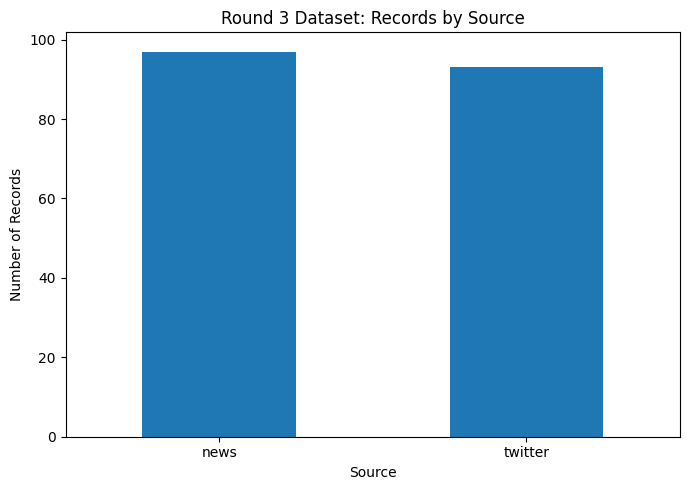

In [24]:
# Create a bar chart showing the number of records collected
# from each source.

plt.figure(figsize=(7, 5))

source_counts.plot(kind="bar")

plt.title("Round 3 Dataset: Records by Source")
plt.xlabel("Source")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [25]:
# Extract the calendar date from each timestamp.
# This allows us to examine how data collection and conversation
# volume changed across the incident timeline.

eda_df["date"] = eda_df["timestamp"].dt.date

# Count records from each source for every day.
daily_volume = (
    eda_df
    .groupby(["date", "source"])
    .size()
    .unstack(fill_value=0)
)

# Add a total column representing all records collected on each day.
daily_volume["total"] = daily_volume.sum(axis=1)

print("Daily record volume:")
display(daily_volume)

Daily record volume:


source,news,twitter,total
date,,,
2026-08-26,22,22,44
2026-08-27,12,18,30
2026-08-28,5,3,8
2026-08-30,0,1,1
2026-08-31,3,2,5
2026-09-01,1,1,2
2026-09-02,0,1,1
2026-09-03,3,0,3
2026-09-04,1,1,2


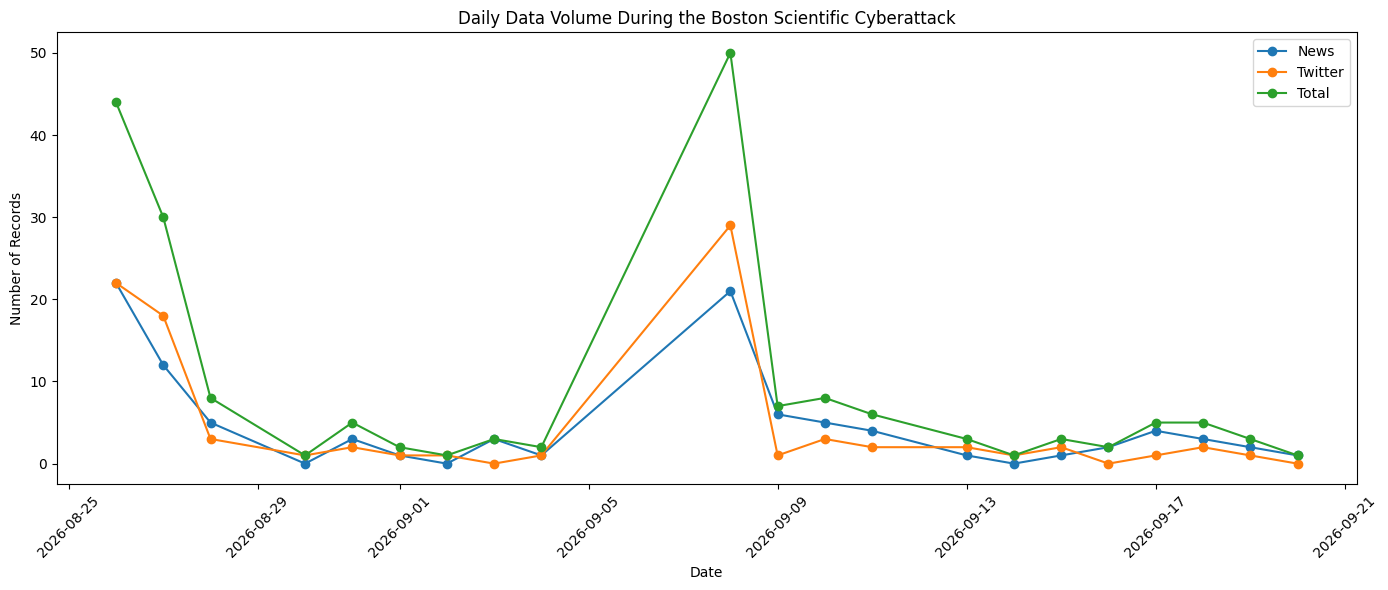

In [26]:
# Plot the number of records collected per day.
# Separate lines are shown for News, Twitter, and the combined dataset
# so that changes in source activity can be compared.

plt.figure(figsize=(14, 6))

if "news" in daily_volume.columns:
    plt.plot(
        daily_volume.index,
        daily_volume["news"],
        marker="o",
        label="News"
    )

if "twitter" in daily_volume.columns:
    plt.plot(
        daily_volume.index,
        daily_volume["twitter"],
        marker="o",
        label="Twitter"
    )

plt.plot(
    daily_volume.index,
    daily_volume["total"],
    marker="o",
    label="Total"
)

plt.title("Daily Data Volume During the Boston Scientific Cyberattack")
plt.xlabel("Date")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

###X engagement summary

In [27]:
# Select only X/Twitter records because engagement metrics are available
# for these records, while News engagement values are missing.
x_eda = eda_df[
    eda_df["source"] == "twitter"
].copy()

# Calculate total engagement for each X post by adding likes,
# comments, and shares.
x_eda["total_engagement"] = (
    x_eda["likes"]
    + x_eda["comments"]
    + x_eda["shares"]
)

# Display summary statistics for the three engagement metrics
# and the combined engagement measure.
engagement_summary = x_eda[
    ["likes", "comments", "shares", "total_engagement"]
].describe()

print("X/Twitter Engagement Summary:")
display(engagement_summary)

X/Twitter Engagement Summary:


,likes,comments,shares,total_engagement
count,93.000000,93.000000,93.000000,93.000000
mean,5.634409,1.010753,1.774194,8.419355
std,11.279825,2.768199,4.237845,16.724314
min,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,2.000000
50%,3.000000,0.000000,1.000000,4.000000
75%,6.000000,1.000000,1.000000,7.000000
max,95.000000,22.000000,30.000000,116.000000


In [28]:
# Sort X posts by total engagement to identify the posts
# that generated the highest observable interaction.
top_engagement = (
    x_eda[
        [
            "text_id",
            "post_text",
            "timestamp",
            "likes",
            "comments",
            "shares",
            "total_engagement"
        ]
    ]
    .sort_values("total_engagement", ascending=False)
    .head(10)
)

print("Top 10 X posts by total engagement:")
display(top_engagement)

Top 10 X posts by total engagement:


,text_id,post_text,timestamp,likes,comments,shares,total_engagement
142,2097419837270118678,"A cyberattack stopped Boston Scientific from shipping medical devices to hospitals and clinics for more than a week. In a recent update the company said its systems still weren't restored, and gav...",2026-09-08 20:20:32+00:00,95.0,5.0,16.0,116.0
24,2092588048303153324,"JUST IN: Boston Scientific shares fall after a cyberattack disrupts the medical device maker's operations, including shipment services, with no clear timeline for restoring systems.",2026-08-26 12:20:43+00:00,42.0,22.0,30.0,94.0
123,2097284062855545328,"Boston Scientific said it likely won’t meet its financial guidance due to the cyberattack that has disrupted its operations, sending shares of the medical-technology company down sharply in premar...",2026-09-08 11:21:00+00:00,23.0,10.0,15.0,48.0
29,2092618837174718591,"Medical device maker Boston Scientific said a cyberattack disrupted its global operations, including systems it relies on to process and ship customer orders. https://t.co/yUN0zI7THN",2026-08-26 14:23:04+00:00,18.0,6.0,15.0,39.0
38,2092652092464763376,"Boston Scientific hit by cyberattack, global operations affected https://t.co/wcYAeUV9nl https://t.co/wcYAeUV9nl",2026-08-26 16:35:13+00:00,24.0,2.0,8.0,34.0
128,2097302700886982801,"Boston Scientific says a cybersecurity incident has impacted its ability to ship its products to customers, and will cause it to miss its forecasts for the year https://t.co/tOYZmbrraY",2026-09-08 12:35:04+00:00,21.0,7.0,3.0,31.0
32,2092633061913452554,Boston Scientific says cyberattack disrupted operations globally\nhttps://t.co/eXCfLPk8Fa\n\nhttps://t.co/eXCfLPk8Fa,2026-08-26 15:19:35+00:00,17.0,3.0,8.0,28.0
72,2093059006814163437,🇺🇸🚨 BOSTON SCIENTIFIC DISCLOSES CYBERATTACK CAUSING GLOBAL OPERATIONAL DISRUPTION\n\nBoston Scientific Corporation has disclosed a cybersecurity incident affecting certain IT systems and disruptin...,2026-08-27 19:32:09+00:00,17.0,3.0,4.0,24.0
42,2092713737660616816,"Boston Scientific hit by cyberattack, global operations affected https://t.co/uMXuVeCL1v https://t.co/uMXuVeCL1v",2026-08-26 20:40:10+00:00,9.0,1.0,8.0,18.0
90,2095078256445739104,Did 1 of @bostonsci visa workers get careless w/ cybersecurity @SecMullinDHS @SecKennedy @howardlutnick? (thread)\n\nhttps://t.co/bvpYCzk07S,2026-09-02 09:15:55+00:00,11.0,1.0,4.0,16.0


In [29]:
# Aggregate X/Twitter engagement by day.
# This allows us to identify dates where overall engagement was
# unusually high, rather than relying only on one highly engaged post.

daily_engagement = (
    x_eda
    .groupby(x_eda["timestamp"].dt.date)
    .agg(
        posts=("text_id", "count"),
        likes=("likes", "sum"),
        comments=("comments", "sum"),
        shares=("shares", "sum"),
        total_engagement=("total_engagement", "sum")
    )
    .sort_values("total_engagement", ascending=False)
)

print("Daily X/Twitter engagement:")
display(daily_engagement)

Daily X/Twitter engagement:


,posts,likes,comments,shares,total_engagement
timestamp,,,,,
2026-09-08,29,237.0,43.0,53.0,333.0
2026-08-26,22,143.0,40.0,84.0,267.0
2026-08-27,18,71.0,7.0,14.0,92.0
2026-09-02,1,11.0,1.0,4.0,16.0
2026-08-28,3,10.0,0.0,2.0,12.0
2026-09-09,1,9.0,0.0,1.0,10.0
2026-08-30,1,7.0,0.0,2.0,9.0
2026-09-04,1,8.0,1.0,0.0,9.0
2026-08-31,2,6.0,0.0,1.0,7.0


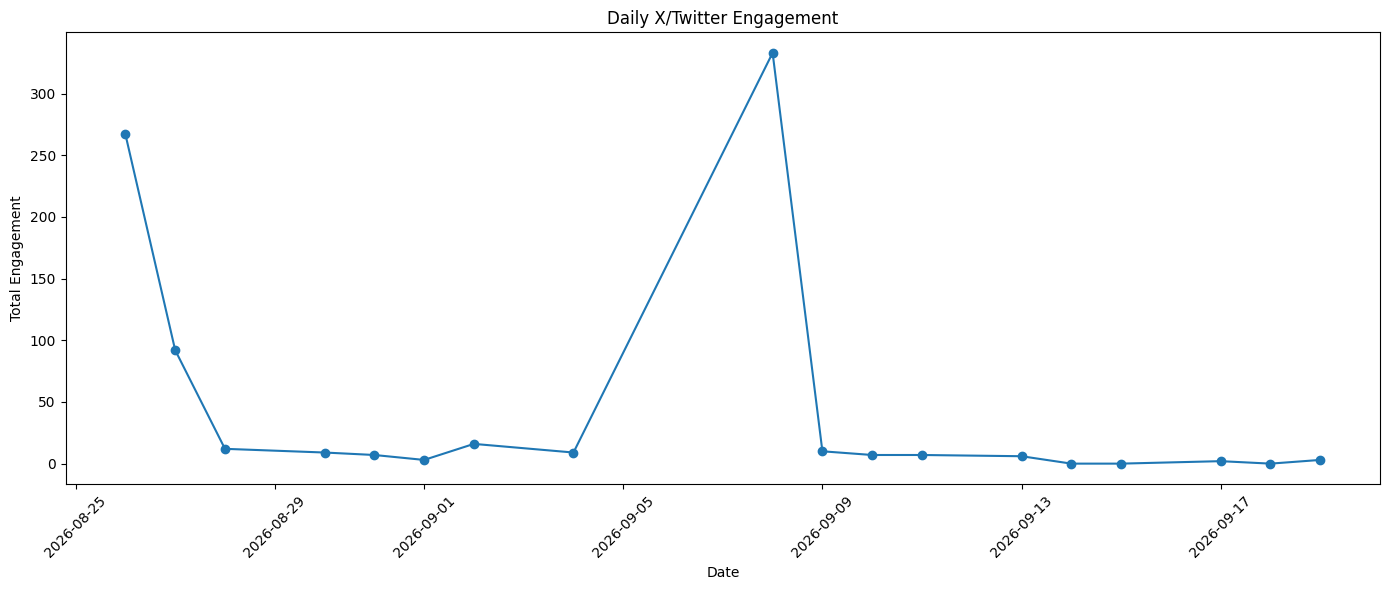

In [30]:
# Plot total X/Twitter engagement for each day.
# The plot helps visually identify the strongest engagement period
# during the cybersecurity incident.

daily_engagement_plot = daily_engagement.sort_index()

plt.figure(figsize=(14, 6))

plt.plot(
    daily_engagement_plot.index,
    daily_engagement_plot["total_engagement"],
    marker="o"
)

plt.title("Daily X/Twitter Engagement")
plt.xlabel("Date")
plt.ylabel("Total Engagement")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [31]:
# Identify the day with the highest total X/Twitter engagement.
# We also calculate how much higher this value is than the mean
# daily engagement across the collected X records.

peak_date = daily_engagement["total_engagement"].idxmax()
peak_engagement = daily_engagement.loc[
    peak_date, "total_engagement"
]

mean_daily_engagement = daily_engagement["total_engagement"].mean()

print("Peak engagement date:", peak_date)
print("Peak total engagement:", peak_engagement)
print("Mean daily engagement:", round(mean_daily_engagement, 2))

print(
    "Peak-to-mean ratio:",
    round(peak_engagement / mean_daily_engagement, 2)
)

Peak engagement date: 2026-09-08
Peak total engagement: 333.0
Mean daily engagement: 43.5
Peak-to-mean ratio: 7.66


### Engagement Spike — Initial Finding

The X/Twitter engagement analysis shows a clear spike on **8 September 2026**.

The day recorded **333 total engagements across 29 posts**, which was approximately **7.66 times the mean daily engagement** of 43.5 across the collected X activity days.

This was also the highest-volume day in the overall dataset, with **50 records** collected across X and News. The concentration of both posting activity and engagement on 8 September makes this date an important period for further investigation.

The next analysis will examine the content and sentiment of posts around this period to identify the developments associated with the observed activity increase.

### Text- length Analysis

In [32]:
# Calculate the number of characters and words in each collected text.
# This helps us understand the basic structure of the text data
# before applying the Round 2 NLP models.

eda_df["text_char_count"] = eda_df["post_text"].astype(str).str.len()

eda_df["text_word_count"] = (
    eda_df["post_text"]
    .astype(str)
    .str.split()
    .str.len()
)

# Display summary statistics for both text-length measures.
text_length_summary = eda_df[
    ["text_char_count", "text_word_count"]
].describe()

print("Text Length Summary:")
display(text_length_summary)

Text Length Summary:


,text_char_count,text_word_count
count,190.000000,190.000000
mean,377.363158,53.163158
std,1285.473618,185.876644
min,59.000000,7.000000
25%,85.000000,10.000000
50%,100.500000,14.000000
75%,158.250000,22.000000
max,12749.000000,1822.000000


In [33]:
# Compare text length between X/Twitter posts and News records.
# This helps determine whether the two sources have substantially
# different text characteristics.

source_text_length = (
    eda_df
    .groupby("source")[["text_char_count", "text_word_count"]]
    .agg(["mean", "median", "min", "max"])
)

print("Text Length by Source:")
display(source_text_length)

Text Length by Source:


text_char_count                   text_word_count                 
                   mean median min    max            mean median min   max
source                                                                    
news          91.927835   88.0  59    143       12.701031   12.0   8    23
twitter      675.075269  159.0  75  12749       95.365591   22.0   7  1822

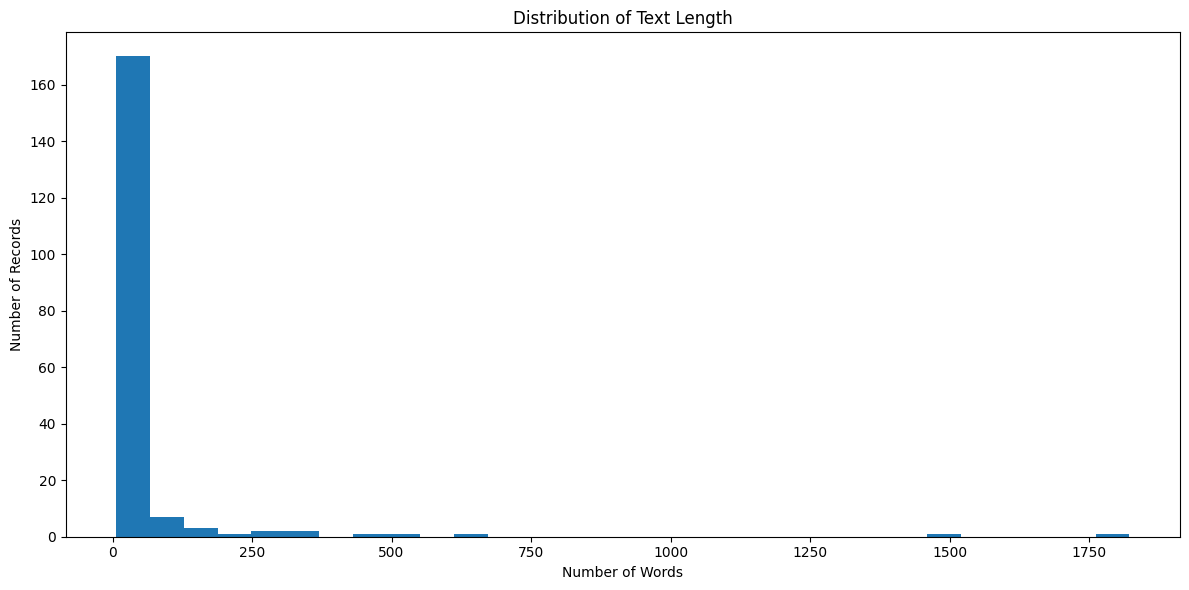

In [34]:
# Plot the distribution of word counts across all collected records.
# The histogram helps identify whether most texts are short and
# whether a small number of very long records create the high mean.

plt.figure(figsize=(12, 6))

plt.hist(
    eda_df["text_word_count"],
    bins=30
)

plt.title("Distribution of Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Records")
plt.tight_layout()

plt.show()

### Initial Finding — Text Characteristics

The text-length analysis shows a strongly right-skewed distribution.

Most collected records are short, while a small number of X/Twitter records contain substantially longer text. The median text length is **14 words** across the complete dataset, compared with a maximum of **1,822 words**.

There is also a clear difference between the two sources. News records have a median length of **12 words**, whereas X/Twitter records have a median length of **22 words**. A small number of unusually long X records increase the mean substantially.

Therefore, median text length provides a more representative description of the collected data than the mean. These differences also reflect the different structures of the two sources and will be considered when interpreting the NLP results.

### Frequent Terms

In [37]:
# Create a cleaner list of discussion terms by removing URL-related
# tokens and other common terms that do not represent the incident.

additional_noise = {
    "https", "http", "www", "com", "org", "net",
    "boston", "scientific"
}

clean_term_words = [
    word
    for word in words
    if word not in stop_words
    and word not in additional_noise
]

# Count the cleaned terms and keep the 20 most frequent ones.
clean_term_counts = Counter(clean_term_words)

top_terms_clean = pd.DataFrame(
    clean_term_counts.most_common(20),
    columns=["term", "frequency"]
)

print("Top 20 Frequent Discussion Terms:")
display(top_terms_clean)

Top 20 Frequent Discussion Terms:


,term,frequency
0,cyberattack,155
1,operations,53
2,global,50
3,cybersecurity,45
4,incident,41
5,company,35
6,guidance,33
7,medical,31
8,meet,31
9,sales,30


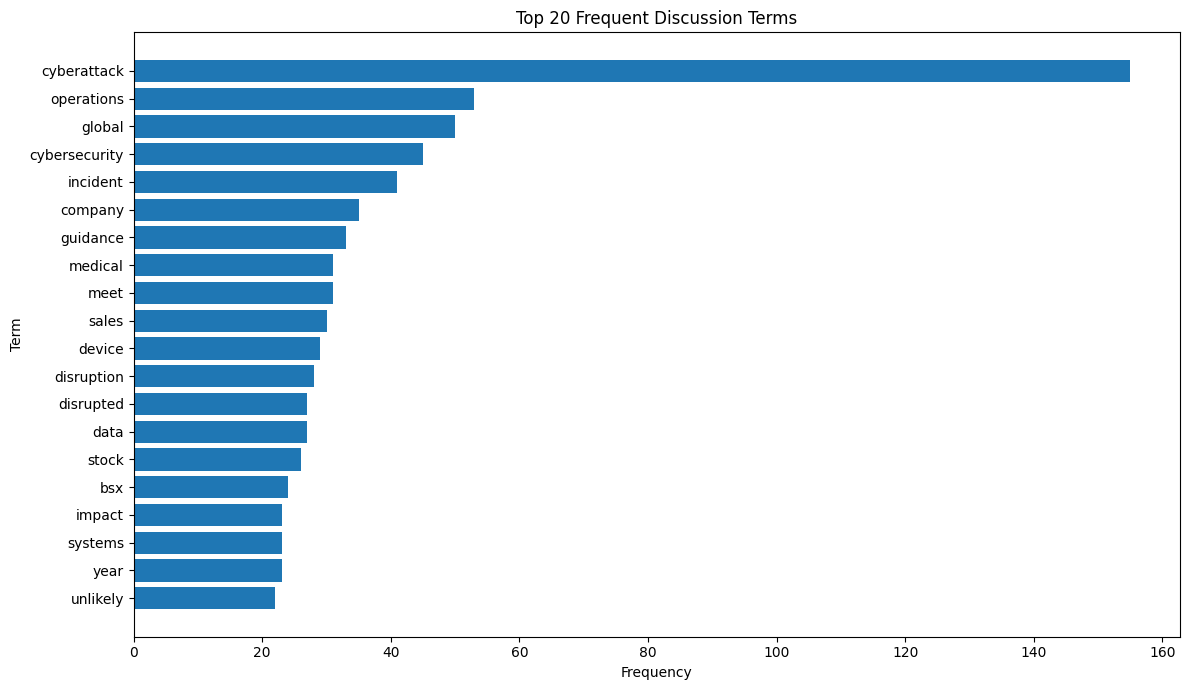

In [41]:
# Plot the cleaned top 20 discussion terms.
# Removing URL artifacts and the company name makes the remaining
# vocabulary more useful for understanding what people discussed.

plt.figure(figsize=(12, 7))

plt.barh(
    top_terms_clean["term"][::-1],
    top_terms_clean["frequency"][::-1]
)

plt.title("Top 20 Frequent Discussion Terms")
plt.xlabel("Frequency")
plt.ylabel("Term")

plt.tight_layout()
plt.show()

### Initial Finding — Frequent Discussion Terms

The frequent-term analysis shows that the collected conversation remained strongly focused on the cybersecurity incident and its operational consequences.

After removing URL-related tokens and generic stopwords, **"cyberattack"** was the most frequent discussion term with **155 occurrences**. Other prominent terms included **operations (53), global (50), cybersecurity (45), incident (41), guidance (33), medical (31), sales (30), device (29), disruption (28), data (27), stock (26),** and **systems (23)**.

The vocabulary indicates that discussion extended beyond the cyberattack itself to its effects on Boston Scientific's operations, medical-device supply, financial guidance, stock performance, and information systems.

These terms provide an initial view of the major discussion themes. The Round 2 topic model will be used later to classify the records into the learned topic categories and examine how these themes changed over time.

## 5. EDA — Key Findings and Incident Timeline

The exploratory analysis provides an initial picture of how the collected conversation was distributed across sources, time, engagement, and content.

### 1. Source Distribution

The final relevance-filtered dataset contains **190 records**:

- **97 News records (51.05%)**
- **93 X/Twitter records (48.95%)**

The nearly balanced source distribution allows the analysis to capture both news coverage and social-media reaction.

### 2. Activity Peaks

Conversation volume was concentrated around two major periods:

- **26 August 2026:** 44 records
- **8 September 2026:** 50 records

Together, these two dates account for **94 of the 190 collected records (49.47%)**.

The first peak corresponds to the initial public disclosure of the cybersecurity incident. Boston Scientific disclosed on August 26 that the incident had caused a global disruption to operations, including limitations affecting order processing and shipping. The company also stated that the timeline for full restoration was not yet known.

The second and larger volume peak occurred on September 8, when Boston Scientific provided additional information about the financial impact of the incident and updated stakeholders on operational recovery. The company stated that it was unlikely to meet its previously issued 2026 sales and adjusted-profit guidance.

### 3. Engagement Spikes

X/Twitter engagement shows two major spikes:

- **26 August:** 267 total engagements across 22 posts
- **8 September:** 333 total engagements across 29 posts

The **8 September spike was the highest**, reaching **333 total engagements**, which was **7.66 times the mean daily engagement of 43.5**.

The two dates also represent different stages of the incident:

- The **26 August spike** coincided with the initial disclosure of the cyberattack and the reported disruption to global operations, including order processing and shipping.
- The **8 September spike** coincided with new information about the incident's financial impact and the company's reduced 2026 financial outlook. The same update also reported progress in restoring affected capabilities.

Therefore, the engagement peaks appear to coincide with the release of significant new information about the incident. This represents an observed temporal association rather than proof that the news directly caused the engagement increase.

### 4. Text Characteristics

The overall text distribution is strongly right-skewed.

Across all 190 records:

- **Median text length:** 14 words
- **Mean text length:** 53.16 words
- **Maximum:** 1,822 words

The source-level medians were:

- **News:** 12 words
- **X/Twitter:** 22 words

A small number of unusually long X/Twitter records substantially increase the mean. Therefore, the median provides a more representative description of typical record length.

### 5. Frequent Discussion Terms

The most frequent meaningful terms were:

- **cyberattack — 155**
- **operations — 53**
- **global — 50**
- **cybersecurity — 45**
- **incident — 41**
- **company — 35**
- **guidance — 33**
- **medical — 31**
- **meet — 31**
- **sales — 30**
- **device — 29**
- **disruption — 28**
- **disrupted — 27**
- **data — 27**
- **stock — 26**
- **BSX — 24**
- **impact — 23**
- **systems — 23**
- **year — 23**
- **unlikely — 22**

The vocabulary indicates several broad discussion areas: the cyberattack itself, operational disruption, medical devices and supply, financial guidance and sales, stock-market impact, and affected information systems.

### Overall EDA Finding

The EDA shows that public discussion was not evenly distributed throughout the collection period. Activity and engagement were concentrated around dates when significant new information about the incident became available.

The **initial disclosure on August 26** was associated with the first major activity and engagement spike, while the **September 8 financial-impact update** coincided with the largest observed activity and engagement spike.

These periods will be examined further using the Round 2 sentiment and topic models to determine whether the nature of the conversation also changed during these high-activity periods.

# 6. Round 2 Sentiment Model

The Round 3 dataset is analysed using the sentiment classification model developed during Round 2.

The selected Round 2 sentiment pipeline consists of:

- **TF-IDF Vectorizer** — converts text into numerical TF-IDF features.
- **Logistic Regression** — predicts one of the three sentiment classes:
  - Negative
  - Neutral
  - Positive

The trained Round 2 model is kept unchanged and is applied directly to the newly collected Round 3 data. This allows the analysis to examine how sentiment evolves in the new conversation rather than retraining the model on the Round 3 dataset.

### Round 2 Sentiment Model Details

The sentiment model selected in Round 2 was **TF-IDF + Logistic Regression**.

The Round 2 evaluation reported:

- Accuracy: **0.5734**
- Macro Precision: **0.5731**
- Macro Recall: **0.5730**
- Macro F1-score: **0.5730**

The model was trained to classify text into **Negative, Neutral, and Positive** sentiment categories.

For Round 3, the same trained TF-IDF representation and Logistic Regression classifier will be used without retraining.

In [46]:
# Load the Round 2 model bundle using joblib.
# The saved model file contains NumPy arrays managed by joblib,
# so joblib.load() is the appropriate loader to try first.
#
# This still loads the original Round 2 models without retraining them.

import joblib

model_path = "Tekton_Round2_Final_NLP_Models.pkl"

round2_models = joblib.load(model_path)

print("Round 2 model bundle loaded successfully.")
print("Bundle type:", type(round2_models))
print("Bundle keys:", round2_models.keys())

Round 2 model bundle loaded successfully.
Bundle type: <class 'dict'>
Bundle keys: dict_keys(['tfidf_vectorizer', 'sentiment_model', 'topic_model'])


In [47]:
# Verify that the loaded Round 2 bundle contains the expected
# vectorizer and the two trained classification models.
# This confirms that we are using the correct Round 2 artifacts
# before applying them to the Round 3 dataset.

tfidf_vectorizer = round2_models["tfidf_vectorizer"]
sentiment_model = round2_models["sentiment_model"]
topic_model = round2_models["topic_model"]

# Print the model and vectorizer types.
print("TF-IDF vectorizer:", type(tfidf_vectorizer).__name__)
print("Sentiment model:", type(sentiment_model).__name__)
print("Topic model:", type(topic_model).__name__)

print()

# Print the class labels learned during Round 2.
print("Sentiment classes:", sentiment_model.classes_)
print("Topic classes:", topic_model.classes_)

print()

# Print the number of TF-IDF features in the original Round 2 vectorizer.
print(
    "Number of TF-IDF features:",
    len(tfidf_vectorizer.get_feature_names_out())
)

TF-IDF vectorizer: TfidfVectorizer
Sentiment model: LogisticRegression
Topic model: LinearSVC

Sentiment classes: ['Negative' 'Neutral' 'Positive']
Topic classes: ['Account_Security' 'Community_Discussion' 'Feature_Feedback'
 'Technical_Issues']

Number of TF-IDF features: 24481


# 7. Sentiment Predictions

In [48]:
# Transform the Round 3 text using the exact TF-IDF vectorizer
# fitted during Round 2.
#
# No new vocabulary is learned here and no retraining is performed.
# This ensures that Round 3 predictions are made using the same
# feature representation as the Round 2 sentiment model.

round3_text = eda_df["post_text"].astype(str)

X_round3_tfidf = tfidf_vectorizer.transform(round3_text)

print("Round 3 text transformed successfully.")
print("Number of records:", X_round3_tfidf.shape[0])
print("Number of TF-IDF features:", X_round3_tfidf.shape[1])

Round 3 text transformed successfully.
Number of records: 190
Number of TF-IDF features: 24481


In [49]:
# Use the unchanged Round 2 Logistic Regression model
# to predict the sentiment of every Round 3 record.
#
# The model predicts one of the three sentiment classes:
# Negative, Neutral, or Positive.
#
# No retraining or fitting is performed on the Round 3 data.

sentiment_predictions = sentiment_model.predict(X_round3_tfidf)

# Store the predictions in a separate analysis dataframe.
# We keep the original EDA dataset unchanged.
sentiment_df = eda_df.copy()

sentiment_df["sentiment_label"] = sentiment_predictions

# Display the number of predictions generated.
print("Sentiment prediction completed.")
print("Number of predictions:", len(sentiment_predictions))

# Display the first few records with their predicted sentiment.
display(
    sentiment_df[
        ["text_id", "source", "post_text", "sentiment_label"]
    ].head(10)
)

Sentiment prediction completed.
Number of predictions: 190


,text_id,source,post_text,sentiment_label
0,news_0049,news,Cyberattack disrupts Boston Scientific as medtech incidents mount - Insurance Business,Negative
1,news_0018,news,"Boston Scientific’s ordering, shipping disrupted in cyberattack - MedTech Dive",Neutral
2,news_0024,news,"Boston Scientific hit by cyberattack, global operations affected - Reuters",Positive
3,news_0011,news,"Boston Scientific says cyberattack disrupted order processing, shipping - Cybersecurity Dive",Negative
4,news_0032,news,Cyberattack on Boston Scientific Disrupts Order Processing - mddionline.com,Neutral
5,news_0021,news,Medical device maker Boston Scientific is being hit by a cyberattack. The shares are falling - CNBC,Negative
6,news_0034,news,Medical device maker Boston Scientific says a cyberattack is causing a 'global disruption' to its operations - TechCrunch,Positive
7,news_0036,news,Medical device firm Boston Scientific says cyberattack has disrupted shipment processes - The Record from Recorded Future News,Neutral
8,news_0082,news,Boston Scientific Hammered On Cybersecurity Attack - Investor's Business Daily,Negative
9,news_0020,news,Boston Scientific Stock Price Drops After Cyberattack Triggers Global Outage - WSJ,Negative


In [50]:
# Count how many Round 3 records were classified into each
# sentiment category by the unchanged Round 2 sentiment model.

sentiment_counts = (
    sentiment_df["sentiment_label"]
    .value_counts()
    .reindex(["Negative", "Neutral", "Positive"], fill_value=0)
)

# Calculate the percentage of Round 3 records in each sentiment class.
sentiment_percentages = (
    sentiment_counts / len(sentiment_df) * 100
).round(2)

# Combine counts and percentages into one readable table.
sentiment_distribution = pd.DataFrame({
    "count": sentiment_counts,
    "percentage": sentiment_percentages
})

print("Round 3 Sentiment Distribution:")
display(sentiment_distribution)

# Verify that every record received exactly one sentiment prediction.
print("Total classified records:", sentiment_counts.sum())

Round 3 Sentiment Distribution:


,count,percentage
sentiment_label,,
Negative,61,32.11
Neutral,96,50.53
Positive,33,17.37


Total classified records: 190


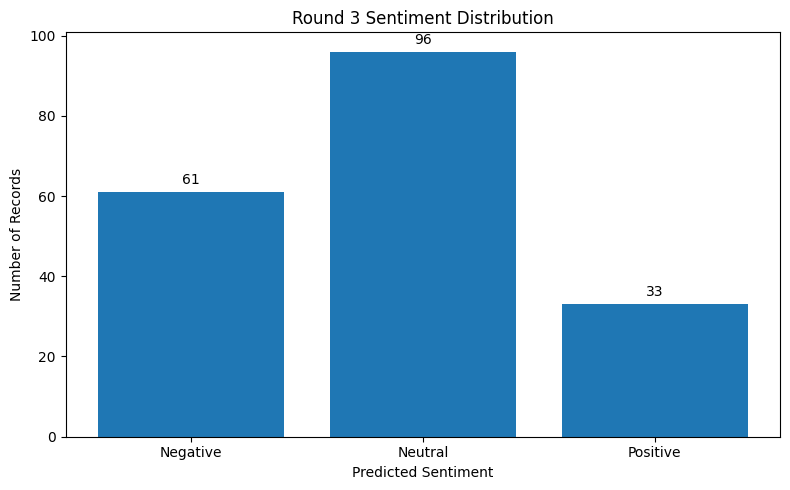

In [51]:
# Create a bar chart showing the distribution of the sentiment
# predictions generated by the unchanged Round 2 model.
#
# The chart uses the exact predicted counts from all 190
# Round 3 records.

sentiment_plot_data = sentiment_distribution.reset_index()

plt.figure(figsize=(8, 5))

plt.bar(
    sentiment_plot_data["sentiment_label"],
    sentiment_plot_data["count"]
)

plt.title("Round 3 Sentiment Distribution")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Number of Records")

# Add the exact count above each bar for readability.
for i, row in sentiment_plot_data.iterrows():
    plt.text(
        i,
        row["count"] + 2,
        str(row["count"]),
        ha="center"
    )

plt.tight_layout()
plt.show()

In [52]:
# Extract the calendar date from each timestamp so that sentiment
# can be compared across the incident timeline.

sentiment_df["date"] = sentiment_df["timestamp"].dt.date

# Count Negative, Neutral, and Positive predictions for each date.
# Reindex the columns so that the sentiment order remains consistent.
daily_sentiment = (
    sentiment_df
    .groupby(["date", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=["Negative", "Neutral", "Positive"],
        fill_value=0
    )
)

# Add the total number of records collected on each date.
daily_sentiment["Total"] = daily_sentiment.sum(axis=1)

print("Daily Sentiment Distribution:")
display(daily_sentiment)

Daily Sentiment Distribution:


sentiment_label,Negative,Neutral,Positive,Total
date,,,,
2026-08-26,10,22,12,44
2026-08-27,9,14,7,30
2026-08-28,2,6,0,8
2026-08-30,1,0,0,1
2026-08-31,1,2,2,5
2026-09-01,0,1,1,2
2026-09-02,1,0,0,1
2026-09-03,1,2,0,3
2026-09-04,1,1,0,2


In [53]:
# Convert the daily sentiment counts into percentages.
# This makes sentiment composition comparable across dates with
# different numbers of collected records.

daily_sentiment_pct = daily_sentiment[
    ["Negative", "Neutral", "Positive"]
].div(
    daily_sentiment["Total"],
    axis=0
) * 100

# Round the percentages for easier interpretation and reporting.
daily_sentiment_pct = daily_sentiment_pct.round(2)

print("Daily Sentiment Percentages:")
display(daily_sentiment_pct)

Daily Sentiment Percentages:


sentiment_label,Negative,Neutral,Positive
date,,,
2026-08-26,22.73,50.00,27.27
2026-08-27,30.00,46.67,23.33
2026-08-28,25.00,75.00,0.00
2026-08-30,100.00,0.00,0.00
2026-08-31,20.00,40.00,40.00
2026-09-01,0.00,50.00,50.00
2026-09-02,100.00,0.00,0.00
2026-09-03,33.33,66.67,0.00
2026-09-04,50.00,50.00,0.00


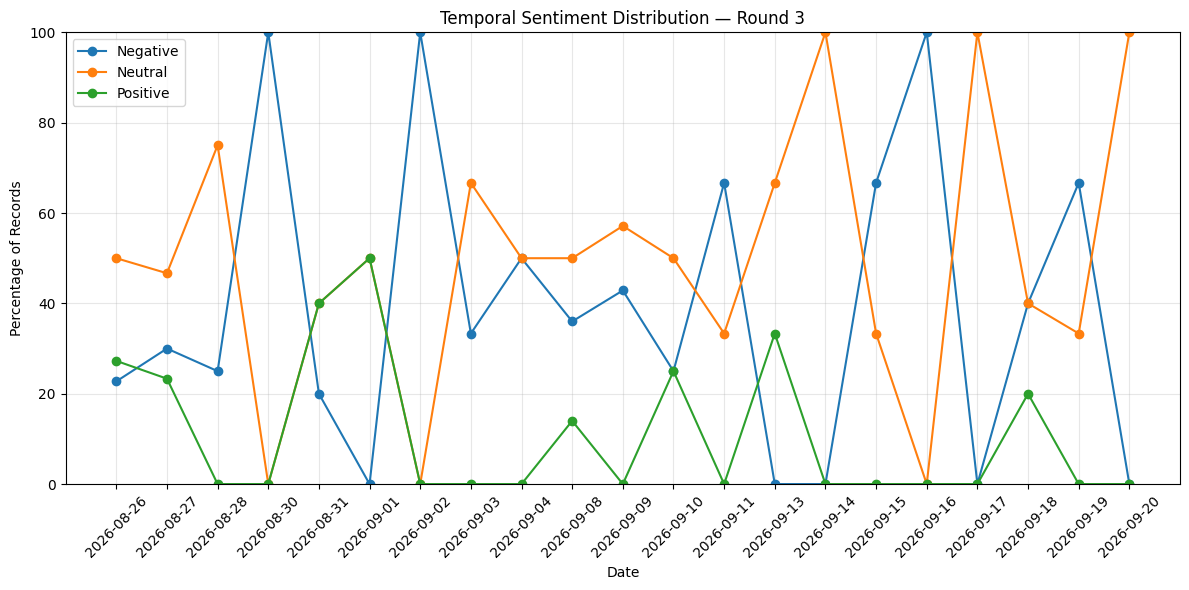

In [54]:
# Plot the percentage of Negative, Neutral, and Positive sentiment
# predictions across the Round 3 timeline.
#
# Each point represents the sentiment composition of the records
# collected on that date. The chart helps identify changes in the
# model-classified sentiment across the incident timeline.

plt.figure(figsize=(12, 6))

plt.plot(
    daily_sentiment_pct.index.astype(str),
    daily_sentiment_pct["Negative"],
    marker="o",
    label="Negative"
)

plt.plot(
    daily_sentiment_pct.index.astype(str),
    daily_sentiment_pct["Neutral"],
    marker="o",
    label="Neutral"
)

plt.plot(
    daily_sentiment_pct.index.astype(str),
    daily_sentiment_pct["Positive"],
    marker="o",
    label="Positive"
)

plt.title("Temporal Sentiment Distribution — Round 3")
plt.xlabel("Date")
plt.ylabel("Percentage of Records")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Temporal Sentiment — Key Insights

The temporal sentiment analysis shows that model-classified sentiment varied across the different stages of the cybersecurity incident.

- On 26 August, one of the two major high-volume periods, the dataset contained 22.73% Negative, 50.00% Neutral, and 27.27% Positive predictions across 44 records.

- On 8 September, the largest activity period with 50 records, the distribution changed to 36.00% Negative, 50.00% Neutral, and 14.00% Positive.

- Compared with 26 August, the Negative share increased by 13.27 percentage points on 8 September, while the Positive share decreased by 13.27 percentage points. The Neutral share remained unchanged at 50.00%.

- This represents a noticeable change in the model-classified sentiment composition between the two major incident periods, with the later period containing a higher proportion of Negative predictions and a lower proportion of Positive predictions.

- Smaller-volume dates show larger percentage fluctuations. For example, 30 August and 2 September were classified as 100% Negative, but each date contains only one record. These dates are therefore not treated as strong evidence of a sentiment shift.

- A higher Negative proportion was also observed on 11 September, at 66.67% across six records. However, the smaller sample size means this observation should be interpreted cautiously.

### Key Sentiment Shift

The most meaningful comparison is between the two high-volume periods of 26 August and 8 September. The model-classified Negative sentiment increased from 22.73% to 36.00%, while Positive sentiment decreased from 27.27% to 14.00%.

This temporal change will be examined alongside the engagement spikes, discussion topics, and incident updates to identify potential triggers associated with the observed change. The analysis describes temporal association and does not establish that a particular event directly caused the sentiment change.

# 8. Round 2 Topic Model

The Round 2 topic classification model is applied to the Round 3 cybersecurity incident data without retraining.

The selected Round 2 model is:

- **TF-IDF + Linear SVM (LinearSVC)**

The model was trained during Round 2 to classify text into four learned topic categories:

- Account_Security
- Community_Discussion
- Feature_Feedback
- Technical_Issues

The same Round 2 TF-IDF vectorizer is used to transform the Round 3 text so that the topic model receives the same feature representation used during training.

In [55]:
# Verify that the exact Round 2 topic model is ready for prediction.
# The model is the original LinearSVC classifier trained during Round 2.
#
# No fitting or retraining is performed on the Round 3 dataset.

print("Round 2 topic model:", type(topic_model).__name__)
print("Topic classes:", topic_model.classes_)
print("Number of Round 3 records:", X_round3_tfidf.shape[0])
print("Number of TF-IDF features:", X_round3_tfidf.shape[1])

Round 2 topic model: LinearSVC
Topic classes: ['Account_Security' 'Community_Discussion' 'Feature_Feedback'
 'Technical_Issues']
Number of Round 3 records: 190
Number of TF-IDF features: 24481


# 9. Topic Predictions

In [56]:
# Use the unchanged Round 2 LinearSVC topic model to classify
# every Round 3 record into one of the four learned topic categories.
#
# No retraining or fitting is performed on the Round 3 data.

topic_predictions = topic_model.predict(X_round3_tfidf)

# Add the topic predictions to the existing analysis dataframe.
# The original EDA dataset remains unchanged.
topic_df = sentiment_df.copy()

topic_df["topic_category"] = topic_predictions

# Verify that every Round 3 record received one topic prediction.
print("Topic prediction completed.")
print("Number of predictions:", len(topic_predictions))

# Display the first 10 predictions for inspection.
display(
    topic_df[
        ["text_id", "source", "post_text", "topic_category"]
    ].head(10)
)

Topic prediction completed.
Number of predictions: 190


,text_id,source,post_text,topic_category
0,news_0049,news,Cyberattack disrupts Boston Scientific as medtech incidents mount - Insurance Business,Community_Discussion
1,news_0018,news,"Boston Scientific’s ordering, shipping disrupted in cyberattack - MedTech Dive",Community_Discussion
2,news_0024,news,"Boston Scientific hit by cyberattack, global operations affected - Reuters",Community_Discussion
3,news_0011,news,"Boston Scientific says cyberattack disrupted order processing, shipping - Cybersecurity Dive",Community_Discussion
4,news_0032,news,Cyberattack on Boston Scientific Disrupts Order Processing - mddionline.com,Community_Discussion
5,news_0021,news,Medical device maker Boston Scientific is being hit by a cyberattack. The shares are falling - CNBC,Community_Discussion
6,news_0034,news,Medical device maker Boston Scientific says a cyberattack is causing a 'global disruption' to its operations - TechCrunch,Community_Discussion
7,news_0036,news,Medical device firm Boston Scientific says cyberattack has disrupted shipment processes - The Record from Recorded Future News,Community_Discussion
8,news_0082,news,Boston Scientific Hammered On Cybersecurity Attack - Investor's Business Daily,Community_Discussion
9,news_0020,news,Boston Scientific Stock Price Drops After Cyberattack Triggers Global Outage - WSJ,Community_Discussion


In [57]:
# Count how many Round 3 records were classified into each
# topic category by the unchanged Round 2 LinearSVC model.

topic_counts = (
    topic_df["topic_category"]
    .value_counts()
    .reindex(
        [
            "Account_Security",
            "Community_Discussion",
            "Feature_Feedback",
            "Technical_Issues"
        ],
        fill_value=0
    )
)

# Calculate the percentage of Round 3 records in each topic category.
topic_percentages = (
    topic_counts / len(topic_df) * 100
).round(2)

# Combine counts and percentages into one readable table.
topic_distribution = pd.DataFrame({
    "count": topic_counts,
    "percentage": topic_percentages
})

print("Round 3 Topic Distribution:")
display(topic_distribution)

# Verify that every Round 3 record received exactly one topic prediction.
print("Total classified records:", topic_counts.sum())

Round 3 Topic Distribution:


,count,percentage
topic_category,,
Account_Security,0,0.00
Community_Discussion,182,95.79
Feature_Feedback,0,0.00
Technical_Issues,8,4.21


Total classified records: 190


### Topic Prediction — Initial Findings

The Round 2 topic model produced a highly concentrated topic distribution for the 190 Round 3 records.

- **Community_Discussion:** 182 records (95.79%)
- **Technical_Issues:** 8 records (4.21%)
- **Account_Security:** 0 records (0.00%)
- **Feature_Feedback:** 0 records (0.00%)

The model therefore classified almost the entire Round 3 dataset as **Community_Discussion**, with a small number of records classified as **Technical_Issues**.

This strong concentration should be interpreted as a characteristic of the Round 2 classifier output rather than as a direct measurement of the true distribution of public discussion topics. The Round 2 evaluation showed class imbalance in the topic dataset and a tendency of the model to overpredict the Community_Discussion class.

The absence of Account_Security and Feature_Feedback predictions also indicates that the Round 2 topic model did not assign any Round 3 records to these two learned categories.

Therefore, the topic predictions will be analysed further at the **record and temporal levels** to determine whether the small Technical_Issues group is concentrated around particular stages of the incident and whether topic composition changes during the major activity periods.

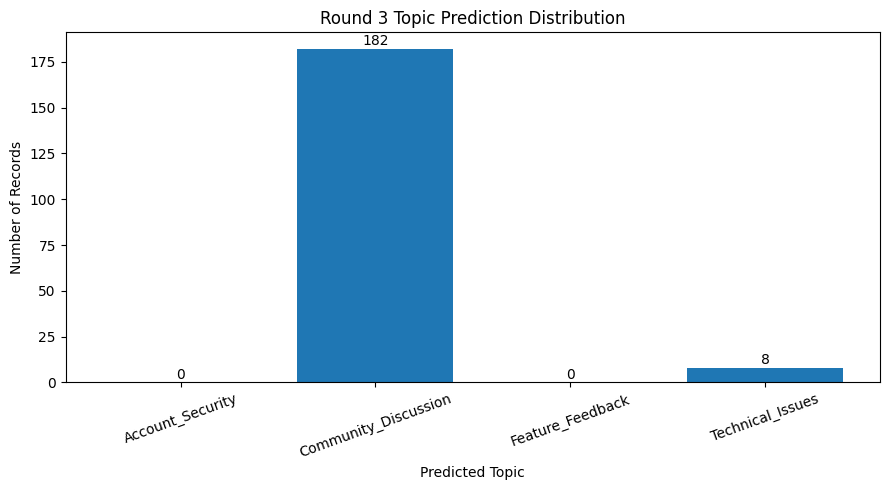

In [58]:
# Create a bar chart showing the distribution of Round 2 topic
# predictions across all 190 Round 3 records.
#
# The chart displays all four learned topic classes, including
# classes that received zero predictions.

topic_plot_data = topic_distribution.reset_index()

plt.figure(figsize=(9, 5))

plt.bar(
    topic_plot_data["topic_category"],
    topic_plot_data["count"]
)

plt.title("Round 3 Topic Prediction Distribution")
plt.xlabel("Predicted Topic")
plt.ylabel("Number of Records")

# Add the exact count above each bar.
for i, row in topic_plot_data.iterrows():
    plt.text(
        i,
        row["count"] + 2,
        str(row["count"]),
        ha="center"
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [59]:
# Extract the records that the Round 2 topic model classified
# as Technical_Issues.
#
# This lets us examine whether these predictions are concentrated
# around a particular date or stage of the cybersecurity incident.

technical_issues_df = topic_df[
    topic_df["topic_category"] == "Technical_Issues"
].copy()

# Convert timestamps to UTC datetime format for temporal analysis.
technical_issues_df["timestamp"] = pd.to_datetime(
    technical_issues_df["timestamp"],
    utc=True,
    errors="coerce"
)

# Display the date, source, text, and predicted topic
# for all Technical_Issues records.
display(
    technical_issues_df[
        ["text_id", "source", "timestamp", "post_text", "topic_category"]
    ].sort_values("timestamp")
)

,text_id,source,timestamp,post_text,topic_category
68,2093008583705190572,twitter,2026-08-27 16:11:47+00:00,If you have a Boston Scientific pacemaker/defib. Your transmitter may be failing to transmit daily. I’ve never had a problem before this cyberattack. Getting a new box and transmitter but no e...,Technical_Issues
79,2093350194347745434,twitter,2026-08-28 14:49:13+00:00,📢Boston Scientific cybersecurity incident – BHRS update\n\nNo impact to device function or remote monitoring for patients enrolled before 25/8/26.\n\nBHRS has published an update for clinical team...,Technical_Issues
123,2097284062855545328,twitter,2026-09-08 11:21:00+00:00,"Boston Scientific said it likely won’t meet its financial guidance due to the cyberattack that has disrupted its operations, sending shares of the medical-technology company down sharply in premar...",Technical_Issues
125,2097288983856263333,twitter,2026-09-08 11:40:34+00:00,🔔 Boston Scientific cybersecurity update\n\nAll LATITUDE services are now functioning normally. Affected patients and those with new implants can now be enrolled.\n\nFull update: https://t.co/Uu7M...,Technical_Issues
126,2097291364551500214,twitter,2026-09-08 11:50:01+00:00,"$BSX 47.80 down 2 identified a cybersecurity incident affecting certain information technology systems and resulting in a global disruption to its operations, the company said in a F...",Technical_Issues
134,2097356609685262403,twitter,2026-09-08 16:09:17+00:00,"$BSX just showed why cybersecurity is now an operating risk, not an IT expense.\n\nAn August 25 cyberattack disrupted manufacturing and order fulfillment badly enough that Boston Scientific now ex...",Technical_Issues
139,2097392567709204608,twitter,2026-09-08 18:32:10+00:00,"Boston Scientific stock sank after cyberattack knocked out its 2026 forecast: The medical device maker said it is unlikely to meet its full-year sales growth and adjusted earnings targets, and wil...",Technical_Issues
142,2097419837270118678,twitter,2026-09-08 20:20:32+00:00,"A cyberattack stopped Boston Scientific from shipping medical devices to hospitals and clinics for more than a week. In a recent update the company said its systems still weren't restored, and gav...",Technical_Issues


### Temporal Distribution of Technical_Issues Predictions

The Round 2 topic model produced only 8 Technical_Issues predictions across the 190 Round 3 records.

These predictions were concentrated in two periods:

- **27–28 August:** 2 Technical_Issues predictions, both related to Boston Scientific device or remote-monitoring concerns following the cybersecurity incident.
- **8 September:** 6 Technical_Issues predictions, representing 75.00% of all Technical_Issues predictions in the dataset.

The 8 September records covered several operational and technical aspects of the incident, including restoration of LATITUDE services, disruption to information technology systems, manufacturing and order-fulfillment disruption, shipping delays, and continued system-recovery updates.

The concentration of Technical_Issues predictions on 8 September coincides with the largest overall activity period in the dataset, which contained 50 records.

This suggests that the Round 2 model's Technical_Issues predictions became more visible during periods containing concrete operational and system-related updates. However, because the Round 2 topic model strongly favoured Community_Discussion, these predictions should be interpreted as model classifications rather than as a complete representation of the actual topic distribution.

In [60]:
# Create a date column from the prediction timestamps so that
# topic distributions can be compared across major incident dates.

topic_df["date"] = pd.to_datetime(
    topic_df["timestamp"],
    utc=True,
    errors="coerce"
).dt.date

# Select the two highest-volume dates identified during EDA:
# 26 August and 8 September 2026.

peak_dates = [
    pd.Timestamp("2026-08-26").date(),
    pd.Timestamp("2026-09-08").date()
]

# Count the predicted topic categories for each of the two
# major activity periods.

peak_topic_counts = (
    topic_df[topic_df["date"].isin(peak_dates)]
    .groupby(["date", "topic_category"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "Account_Security",
            "Community_Discussion",
            "Feature_Feedback",
            "Technical_Issues"
        ],
        fill_value=0
    )
)

# Calculate the percentage distribution within each date.
# This allows comparison even though the two dates have
# different total record counts.

peak_topic_percentages = (
    peak_topic_counts
    .div(peak_topic_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

print("Topic Distribution — Major Activity Periods")
display(peak_topic_counts)

print("Topic Percentage Distribution — Major Activity Periods")
display(peak_topic_percentages)

Topic Distribution — Major Activity Periods


topic_category,Account_Security,Community_Discussion,Feature_Feedback,Technical_Issues
date,,,,
2026-08-26,0,44,0,0
2026-09-08,0,44,0,6


Topic Percentage Distribution — Major Activity Periods


topic_category,Account_Security,Community_Discussion,Feature_Feedback,Technical_Issues
date,,,,
2026-08-26,0.0,100.0,0.0,0.0
2026-09-08,0.0,88.0,0.0,12.0


### Topic Composition Across Major Activity Periods

The two highest-volume periods show a change in the Round 2 model's predicted topic composition.

On **26 August**, all 44 records were classified as **Community_Discussion (100.00%)**, with no records classified as Technical_Issues.

On **8 September**, 44 of 50 records were classified as **Community_Discussion (88.00%)**, while 6 records (12.00%) were classified as **Technical_Issues**.

Therefore, the Technical_Issues share increased from **0.00% on 26 August to 12.00% on 8 September**, while the Community_Discussion share decreased from 100.00% to 88.00%.

The six Technical_Issues predictions on 8 September corresponded to posts discussing operational disruption, information-system impact, service restoration, manufacturing/order-fulfillment disruption, shipping disruption, and financial consequences associated with the incident.

Account_Security and Feature_Feedback received no predictions on either of the two major activity dates.

This change should be interpreted as a change in the **model-classified topic composition**, rather than as proof that the underlying public conversation objectively shifted by the same proportions. The Round 2 topic model was strongly biased toward the Community_Discussion class.

# 10. Temporal Sentiment Analysis

This section examines how the Round 2 model's sentiment predictions changed over the analysis period.

The predicted sentiment labels are grouped by date to identify:

- Daily sentiment composition
- Changes between major activity periods
- Potential sentiment shifts during the cybersecurity incident
- Differences between high-volume and low-volume periods

Because the sentiment labels are predictions from the Round 2 TF-IDF + Logistic Regression model, the results represent **model-classified sentiment** rather than manually verified sentiment.

Particular attention is given to the two highest-volume periods identified during EDA:

- **26 August 2026:** 44 records
- **8 September 2026:** 50 records

These dates provide the most meaningful comparison because they contain substantially more observations than the low-volume dates.

In [61]:
# Create a daily sentiment count table from the Round 2 predictions.
# Each row represents one date and each column represents a
# model-predicted sentiment category.

daily_sentiment = (
    sentiment_df
    .groupby(["date", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=["Negative", "Neutral", "Positive"],
        fill_value=0
    )
)

# Calculate the total number of records for each date.
daily_sentiment["Total"] = daily_sentiment.sum(axis=1)

# Convert the sentiment counts into percentages within each date.
# This allows comparison between dates with different record volumes.

daily_sentiment_pct = (
    daily_sentiment[["Negative", "Neutral", "Positive"]]
    .div(daily_sentiment["Total"], axis=0)
    .mul(100)
    .round(2)
)

# Display the daily sentiment percentages.
print("Daily Sentiment Distribution (%)")
display(daily_sentiment_pct)

# Display the corresponding number of records for each date.
print("Daily Record Counts")
display(daily_sentiment["Total"])

Daily Sentiment Distribution (%)


sentiment_label,Negative,Neutral,Positive
date,,,
2026-08-26,22.73,50.00,27.27
2026-08-27,30.00,46.67,23.33
2026-08-28,25.00,75.00,0.00
2026-08-30,100.00,0.00,0.00
2026-08-31,20.00,40.00,40.00
2026-09-01,0.00,50.00,50.00
2026-09-02,100.00,0.00,0.00
2026-09-03,33.33,66.67,0.00
2026-09-04,50.00,50.00,0.00


Daily Record Counts


,Total
date,
2026-08-26,44
2026-08-27,30
2026-08-28,8
2026-08-30,1
2026-08-31,5
2026-09-01,2
2026-09-02,1
2026-09-03,3
2026-09-04,2


In [62]:
# Extract the sentiment percentages for the two major
# activity periods identified during EDA.

aug26_sentiment = daily_sentiment_pct.loc[
    pd.Timestamp("2026-08-26").date()
]

sep8_sentiment = daily_sentiment_pct.loc[
    pd.Timestamp("2026-09-08").date()
]

# Calculate the change in percentage points from 26 August
# to 8 September for each sentiment category.

sentiment_shift = (
    sep8_sentiment - aug26_sentiment
).round(2)

# Combine the two dates and their change into one table
# for easy interpretation.

sentiment_comparison = pd.DataFrame({
    "26_August_%": aug26_sentiment,
    "8_September_%": sep8_sentiment,
    "Change_pp": sentiment_shift
})

print("Sentiment Comparison — Major Activity Periods")
display(sentiment_comparison)

Sentiment Comparison — Major Activity Periods


,26_August_%,8_September_%,Change_pp
sentiment_label,,,
Negative,22.73,36.0,13.27
Neutral,50.00,50.0,0.00
Positive,27.27,14.0,-13.27


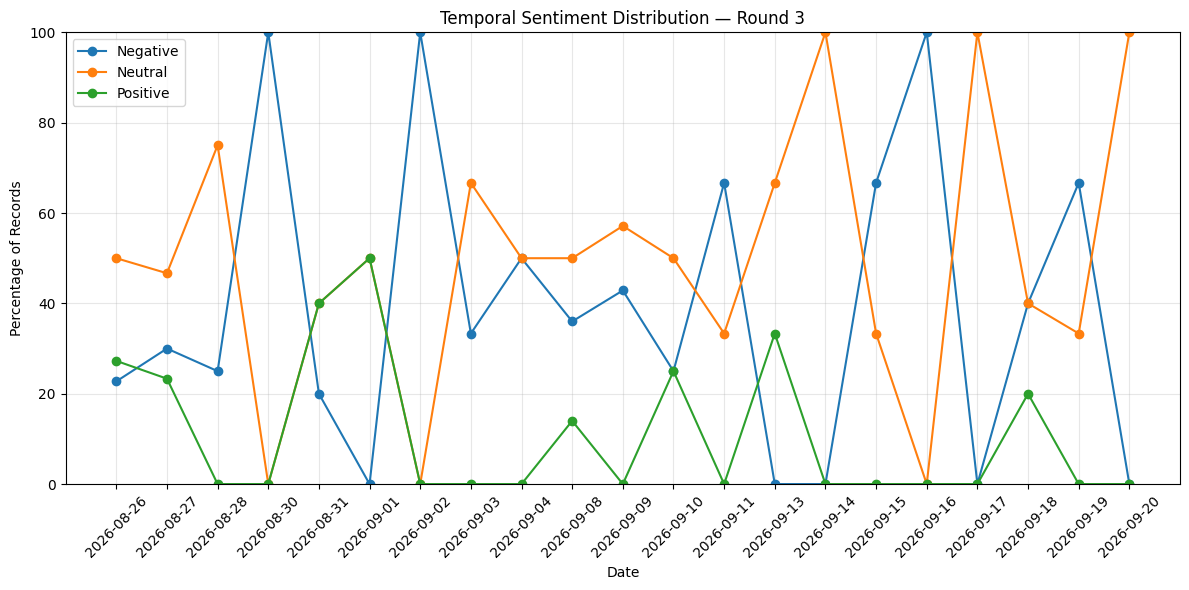

In [63]:
# Plot the daily percentage of each model-predicted sentiment
# category across the Round 3 analysis period.

plt.figure(figsize=(12, 6))

plt.plot(
    daily_sentiment_pct.index.astype(str),
    daily_sentiment_pct["Negative"],
    marker="o",
    label="Negative"
)

plt.plot(
    daily_sentiment_pct.index.astype(str),
    daily_sentiment_pct["Neutral"],
    marker="o",
    label="Neutral"
)

plt.plot(
    daily_sentiment_pct.index.astype(str),
    daily_sentiment_pct["Positive"],
    marker="o",
    label="Positive"
)

# Add chart labels and formatting.
plt.title("Temporal Sentiment Distribution — Round 3")
plt.xlabel("Date")
plt.ylabel("Percentage of Records")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Display the completed sentiment trend chart.
plt.show()

### Temporal Sentiment — Key Insights

The temporal sentiment analysis identified several changes in the model-classified sentiment composition across the cybersecurity incident.

#### Sentiment Shift 1 — 26 August to 8 September

The most important high-volume sentiment shift occurred between the two largest activity periods:

- **26 August:** Negative 22.73%, Neutral 50.00%, Positive 27.27%
- **8 September:** Negative 36.00%, Neutral 50.00%, Positive 14.00%

Therefore:

- Negative sentiment increased by **13.27 percentage points**.
- Positive sentiment decreased by **13.27 percentage points**.
- Neutral sentiment remained unchanged at **50.00%**.

This is the strongest sentiment shift in the two major activity periods because both dates contain substantial numbers of records: 44 on 26 August and 50 on 8 September.

A possible explanation is the change in the information being discussed. The 26 August period corresponds to the initial public discussion of the cybersecurity incident and operational disruption. By 8 September, the conversation included additional information about the financial impact of the incident, updated company guidance, continued operational disruption, and system-recovery developments. The increased proportion of Negative predictions therefore coincided with a period in which the consequences of the incident were more clearly documented.

This represents temporal association rather than proof that these developments directly caused the sentiment change.

#### Sentiment Shift 2 — 26 August to 27 August

A smaller change occurred immediately after the initial high-volume period:

- Negative sentiment increased from **22.73% to 30.00%** (+7.27 percentage points).
- Neutral sentiment decreased from **50.00% to 46.67%** (−3.33 percentage points).
- Positive sentiment decreased from **27.27% to 23.33%** (−3.94 percentage points).

The number of records also decreased from 44 to 30.

This pattern is consistent with a slightly more Negative model-classified composition immediately after the initial incident period. However, the change is smaller than the later 26 August–8 September shift and should therefore be interpreted more cautiously.

#### Sentiment Shift 3 — 8 September to 11 September

Another notable change appears after the 8 September peak:

- Negative sentiment increased from **36.00% on 8 September to 66.67% on 11 September**.
- Neutral sentiment decreased from **50.00% to 33.33%**.
- Positive sentiment decreased from **14.00% to 0.00%**.

However, the number of records fell sharply from **50 to 6**.

Therefore, although the percentage change is large, the smaller sample on 11 September makes this a weaker indication of a broad sentiment shift than the 26 August–8 September comparison.

### Sentiment Model Reliability and Interpretation

These sentiment shifts must be interpreted in the context of the Round 2 model's measured performance.

The selected TF-IDF + Logistic Regression sentiment model achieved **57.34% accuracy, 0.5731 macro precision, 0.5730 macro recall, and 0.5730 macro F1** on the Round 2 test set.

The Round 2 confusion matrix also showed substantial confusion between sentiment classes. The largest error was **Neutral → Negative (189 samples)**, followed by **Positive → Neutral (186)** and **Negative → Neutral (177)**.

This means that the Round 3 sentiment percentages should be treated as **model-classified sentiment patterns rather than ground-truth measurements of public sentiment**.

In particular, changes involving Negative and Neutral should be interpreted cautiously because the Round 2 model demonstrated difficulty distinguishing these categories.

The strongest evidence is therefore the **direction and composition of changes across the larger-volume periods**, rather than treating individual low-volume dates as definitive sentiment measurements.

### Possible Reasons Behind the Observed Sentiment Changes

The observed changes coincide with different stages of the cybersecurity incident:

1. **Initial incident period — 26 August:** Discussion centred on the newly reported cyberattack, operational disruption, shipment/order-processing problems, and uncertainty around restoration.

2. **Financial and operational impact period — 8 September:** Discussion coincided with new information about the company's financial outlook, operational disruption, and system-recovery status. This period also produced the largest overall dataset volume and the highest X engagement.

3. **Post-peak period — 9–11 September:** The conversation became lower-volume, while the model classified a larger proportion of the remaining records as Negative. Because only six records were present on 11 September, this should not be treated as evidence of a broad population-level sentiment change.

Overall, the analysis indicates that the model-classified sentiment became more Negative during the later major incident-update period, while Neutral remained the largest category. The result is informative for temporal analysis, but the moderate sentiment-model performance and documented Neutral-related confusion mean that the findings should be interpreted as **model-based signals rather than definitive measurements of public sentiment**.

# 11. Activity Analysis

Activity analysis examines how public engagement varied during the cybersecurity incident.

Since engagement metrics were available for X (Twitter) records but not for the collected news records, this section focuses on X posts using:

- Likes
- Comments
- Shares
- Total engagement = Likes + Comments + Shares

The analysis identifies major engagement spikes and examines the content associated with those spikes.

Because the dataset is observational and time-based, the analysis identifies events that **coincided with** engagement increases rather than claiming that a particular event directly caused the increase.

In [64]:
# Filter the dataset to X (Twitter) records because engagement metrics
# are available for these records.
x_activity = topic_df[topic_df["source"] == "twitter"].copy()

# Create a date column so that engagement can be aggregated by day.
x_activity["date"] = x_activity["timestamp"].dt.date

# Calculate total engagement for every X post.
# Total engagement is defined as likes + comments + shares.
x_activity["total_engagement"] = (
    x_activity["likes"]
    + x_activity["comments"]
    + x_activity["shares"]
)

# Aggregate the engagement metrics by date.
daily_x_engagement = (
    x_activity
    .groupby("date")
    .agg(
        posts=("text_id", "count"),
        likes=("likes", "sum"),
        comments=("comments", "sum"),
        shares=("shares", "sum"),
        total_engagement=("total_engagement", "sum")
    )
    .reset_index()
    .sort_values("total_engagement", ascending=False)
)

# Display the daily engagement table.
display(daily_x_engagement)

,date,posts,likes,comments,shares,total_engagement
8,2026-09-08,29,237.0,43.0,53.0,333.0
0,2026-08-26,22,143.0,40.0,84.0,267.0
1,2026-08-27,18,71.0,7.0,14.0,92.0
6,2026-09-02,1,11.0,1.0,4.0,16.0
2,2026-08-28,3,10.0,0.0,2.0,12.0
9,2026-09-09,1,9.0,0.0,1.0,10.0
3,2026-08-30,1,7.0,0.0,2.0,9.0
7,2026-09-04,1,8.0,1.0,0.0,9.0
4,2026-08-31,2,6.0,0.0,1.0,7.0
10,2026-09-10,3,5.0,1.0,1.0,7.0


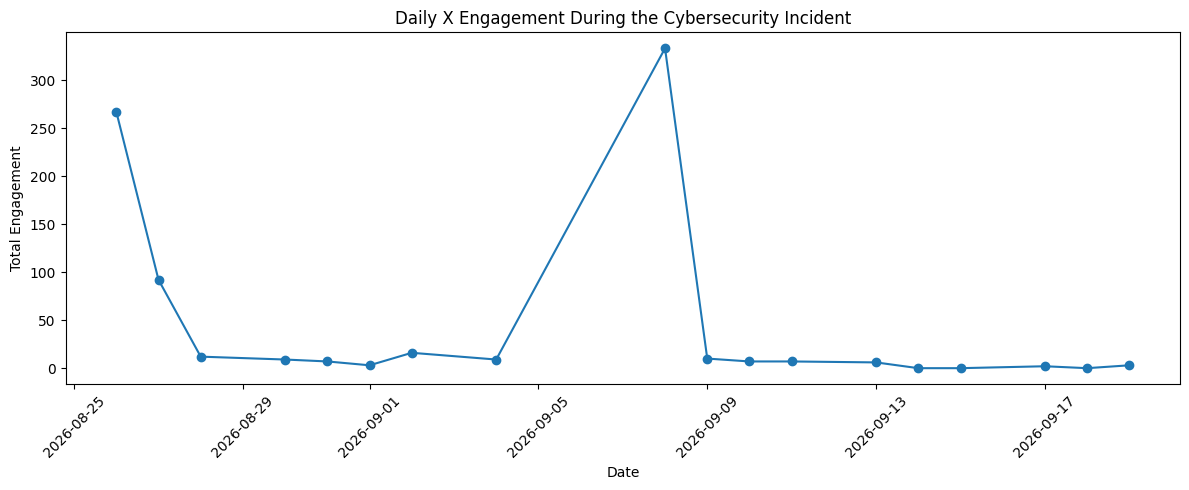

In [65]:
# Sort the daily engagement data chronologically for the time-series plot.
daily_x_engagement_plot = daily_x_engagement.sort_values("date").copy()

# Create a line chart showing total X engagement over time.
plt.figure(figsize=(12, 5))

plt.plot(
    daily_x_engagement_plot["date"],
    daily_x_engagement_plot["total_engagement"],
    marker="o"
)

# Add a title and axis labels to explain the chart.
plt.title("Daily X Engagement During the Cybersecurity Incident")
plt.xlabel("Date")
plt.ylabel("Total Engagement")

# Rotate the date labels so they remain readable.
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [66]:
# Select the two dates with the highest total X engagement.
top_engagement_days = (
    daily_x_engagement
    .sort_values("total_engagement", ascending=False)
    .head(2)
)

# Display the two highest-engagement periods.
display(top_engagement_days)

,date,posts,likes,comments,shares,total_engagement
8,2026-09-08,29,237.0,43.0,53.0,333.0
0,2026-08-26,22,143.0,40.0,84.0,267.0


In [67]:
# Define the two major engagement-spike dates identified above.
spike_dates = [
    pd.to_datetime("2026-09-08").date(),
    pd.to_datetime("2026-08-26").date()
]

# Filter X posts belonging to either of the two spike dates.
spike_posts = x_activity[
    x_activity["date"].isin(spike_dates)
].copy()

# Sort posts by total engagement so that the most-engaged posts
# appear first within the selected periods.
spike_posts = spike_posts.sort_values(
    "total_engagement",
    ascending=False
)

# Display the most-engaged posts from the two major spike dates.
display(
    spike_posts[
        [
            "date",
            "text_id",
            "post_text",
            "likes",
            "comments",
            "shares",
            "total_engagement"
        ]
    ].head(10)
)

,date,text_id,post_text,likes,comments,shares,total_engagement
142,2026-09-08,2097419837270118678,"A cyberattack stopped Boston Scientific from shipping medical devices to hospitals and clinics for more than a week. In a recent update the company said its systems still weren't restored, and gav...",95.0,5.0,16.0,116.0
24,2026-08-26,2092588048303153324,"JUST IN: Boston Scientific shares fall after a cyberattack disrupts the medical device maker's operations, including shipment services, with no clear timeline for restoring systems.",42.0,22.0,30.0,94.0
123,2026-09-08,2097284062855545328,"Boston Scientific said it likely won’t meet its financial guidance due to the cyberattack that has disrupted its operations, sending shares of the medical-technology company down sharply in premar...",23.0,10.0,15.0,48.0
29,2026-08-26,2092618837174718591,"Medical device maker Boston Scientific said a cyberattack disrupted its global operations, including systems it relies on to process and ship customer orders. https://t.co/yUN0zI7THN",18.0,6.0,15.0,39.0
38,2026-08-26,2092652092464763376,"Boston Scientific hit by cyberattack, global operations affected https://t.co/wcYAeUV9nl https://t.co/wcYAeUV9nl",24.0,2.0,8.0,34.0
128,2026-09-08,2097302700886982801,"Boston Scientific says a cybersecurity incident has impacted its ability to ship its products to customers, and will cause it to miss its forecasts for the year https://t.co/tOYZmbrraY",21.0,7.0,3.0,31.0
32,2026-08-26,2092633061913452554,Boston Scientific says cyberattack disrupted operations globally\nhttps://t.co/eXCfLPk8Fa\n\nhttps://t.co/eXCfLPk8Fa,17.0,3.0,8.0,28.0
42,2026-08-26,2092713737660616816,"Boston Scientific hit by cyberattack, global operations affected https://t.co/uMXuVeCL1v https://t.co/uMXuVeCL1v",9.0,1.0,8.0,18.0
130,2026-09-08,2097336682311790700,"Boston Scientific says unlikely to meet 2026 sales, profit forecast after cyberattack https://t.co/gZyeWiWUCo https://t.co/gZyeWiWUCo",8.0,1.0,4.0,13.0
140,2026-09-08,2097399668351148541,"Boston Scientific says unlikely to meet 2026 sales, profit forecast after cyberattack https://t.co/DDc7h5bYKv https://t.co/DDc7h5bYKv",9.0,0.0,4.0,13.0


In [68]:
# Identify the single X post with the highest combined engagement
# across the entire Round 3 dataset.
top_x_post = x_activity.loc[
    x_activity["total_engagement"].idxmax()
]

# Display the post and all available engagement metrics.
display(
    top_x_post[
        [
            "date",
            "text_id",
            "post_text",
            "likes",
            "comments",
            "shares",
            "total_engagement"
        ]
    ]
)

,142
date,2026-09-08
text_id,2097419837270118678
post_text,"A cyberattack stopped Boston Scientific from shipping medical devices to hospitals and clinics for more than a week. In a recent update the company said its systems still weren't restored, and gav..."
likes,95.0
comments,5.0
shares,16.0
total_engagement,116.0


In [69]:
# Calculate the mean daily X engagement across all dates represented
# in the collected X dataset.
mean_daily_engagement = daily_x_engagement["total_engagement"].mean()

# Identify the highest daily engagement value.
peak_daily_engagement = daily_x_engagement["total_engagement"].max()

# Calculate how many times larger the peak was than the mean.
peak_to_mean_ratio = peak_daily_engagement / mean_daily_engagement

# Display the summary statistics.
print(f"Mean daily X engagement: {mean_daily_engagement:.2f}")
print(f"Peak daily X engagement: {peak_daily_engagement}")
print(f"Peak-to-mean ratio: {peak_to_mean_ratio:.2f}x")

Mean daily X engagement: 43.50
Peak daily X engagement: 333.0
Peak-to-mean ratio: 7.66x


### Activity Analysis — Key Insights

The activity analysis shows that X engagement was concentrated around two major periods: **26 August** and **8 September**.

#### Engagement Spike 1 — 26 August

On **26 August**, the dataset recorded:

- **22 X posts**
- **143 likes**
- **40 comments**
- **84 shares**
- **267 total engagements**

The highly engaged posts during this period focused on the initial operational impact of the cyberattack. The most-engaged post received **94 total engagements** and reported that the attack had disrupted Boston Scientific's operations and shipment services, with no clear timeline for system restoration.

Another post with **39 engagements** described disruption to global operations and the systems used to process and ship customer orders.

The high share count on this date (**84 shares**) indicates substantial circulation of incident-related information on X. This period therefore coincided with the initial public discussion of the attack, operational disruption, shipment problems, and uncertainty around restoration.

#### Engagement Spike 2 — 8 September

The largest engagement spike occurred on **8 September**, with:

- **29 X posts**
- **237 likes**
- **43 comments**
- **53 shares**
- **333 total engagements**

This was the highest daily engagement recorded in the dataset and was **7.66 times the mean daily X engagement of 43.50**.

The most-engaged post received **116 total engagements**:

- 95 likes
- 5 comments
- 16 shares

Its content focused on the cyberattack's effect on Boston Scientific's ability to ship medical devices and the fact that affected systems had not yet been fully restored.

Other highly engaged posts on 8 September focused on:

- the company potentially missing financial guidance because of the cyberattack,
- continued disruption to product shipments, and
- the effect of the incident on the company's 2026 sales and profit forecast.

Therefore, the 8 September engagement spike coincided with the emergence of additional information about the **financial consequences, continued operational disruption, and system recovery status** of the incident.

#### Comparison of the Two Engagement Spikes

| Period | X Posts | Likes | Comments | Shares | Total Engagement |
|---|---:|---:|---:|---:|---:|
| 26 August | 22 | 143 | 40 | 84 | 267 |
| 8 September | 29 | 237 | 43 | 53 | 333 |

The two periods represent different stages of the incident:

- **26 August:** Initial disclosure of the cyberattack, global operational disruption, shipment problems, and uncertainty about restoration.
- **8 September:** Later updates concerning continued shipping disruption, financial guidance, sales/profit forecasts, and system recovery.

The engagement increase from **267 on 26 August to 333 on 8 September** therefore coincided with a shift from initial incident reporting toward discussion of the broader operational and financial consequences.

This is a **temporal association** and should not be interpreted as proof that these developments directly caused the increase in engagement.

### Overall Activity Finding

The strongest activity signal in the collected X data occurred on **8 September**, when both the number of X posts and total engagement reached their highest levels.

The analysis shows that engagement spikes were associated with posts containing **new or consequential information about the cybersecurity incident**, particularly operational disruption, shipping impact, financial guidance, and recovery status.

This supports the observation that public activity in the collected dataset was concentrated around major incident updates rather than being evenly distributed throughout the analysis period.

# 12. Topic & Entity Analysis

This section examines the main discussion themes and entities appearing in the Round 3 cybersecurity incident data.

Two complementary approaches are used:

1. **Round 2 topic classification** using the unchanged TF-IDF + Linear SVM model.
2. **Text-based topic and entity analysis** using frequently occurring terms from the collected records.

The Round 2 topic predictions are treated as model-based signals rather than ground-truth topic proportions because the Round 2 model showed a strong tendency toward the Community_Discussion class.

The text-based analysis is therefore used alongside the model predictions to identify the concrete subjects being discussed, such as:

- Cyberattack and cybersecurity
- Operational disruption
- Medical devices
- Shipping and order fulfilment
- Financial guidance and sales
- Information systems and recovery
- Stock-market impact

The analysis also examines how these discussion themes changed between the major activity periods of **26 August** and **8 September** and identifies incident updates that coincided with those changes.

In [71]:
# Combine all Round 3 post text into one text corpus.
# Converting everything to lowercase makes the frequency analysis
# case-insensitive.
all_text = " ".join(
    topic_df["post_text"].astype(str).str.lower()
)

# Remove URLs before extracting individual words.
# This prevents terms such as "https", "http", "www", and URL fragments
# from being counted as discussion topics.
all_text = re.sub(
    r"https?://\S+|www\.\S+",
    " ",
    all_text
)

# Extract alphabetic words containing at least three characters.
# URL-related fragments have already been removed above.
tokens = re.findall(
    r"\b[a-zA-Z]{3,}\b",
    all_text
)

# Define common English words that do not represent meaningful
# discussion topics, along with the company name.
stop_words = {
    "the", "and", "for", "that", "with", "this", "from",
    "said", "its", "was", "are", "has", "have", "had",
    "but", "not", "will", "about", "they", "their",
    "you", "into", "after", "before", "been", "were",
    "than", "more", "also", "can", "may", "would",
    "could", "what", "when", "which", "who", "how",
    "where", "while", "over", "under", "through",
    "company", "companies",
    "boston", "scientific"
}

# Remove common words and company-name terms.
filtered_tokens = [
    token
    for token in tokens
    if token not in stop_words
]

# Count the frequency of each remaining term.
term_counts = Counter(filtered_tokens)

# Convert the frequency counts into a dataframe.
term_frequency = pd.DataFrame(
    term_counts.most_common(25),
    columns=["term", "frequency"]
)

# Display the most frequent meaningful discussion terms.
display(term_frequency)

,term,frequency
0,cyberattack,155
1,operations,53
2,global,50
3,cybersecurity,45
4,says,42
5,incident,41
6,com,35
7,guidance,33
8,medical,31
9,meet,31


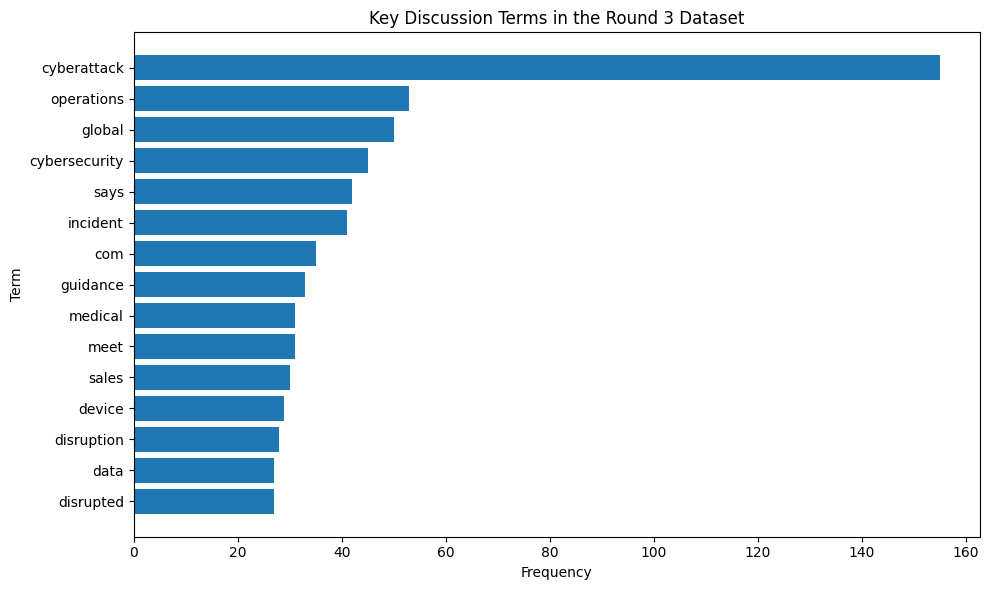

In [72]:
# Select the 15 most frequent meaningful terms for visualization.
top_terms = term_frequency.head(15).sort_values(
    "frequency",
    ascending=True
)

# Create a horizontal bar chart of the most frequent discussion terms.
plt.figure(figsize=(10, 6))

plt.barh(
    top_terms["term"],
    top_terms["frequency"]
)

# Add a descriptive title and axis labels.
plt.title("Key Discussion Terms in the Round 3 Dataset")
plt.xlabel("Frequency")
plt.ylabel("Term")

plt.tight_layout()
plt.show()

###Compare topics across the two major dates

In [73]:
# Define the two major activity dates identified during the EDA
# and activity analysis.
major_dates = [
    pd.to_datetime("2026-08-26").date(),
    pd.to_datetime("2026-09-08").date()
]

# Create a copy of the topic dataframe so the original dataframe
# is not modified during this comparison.
major_period_topics = topic_df.copy()

# Create a date column from the existing timestamp column.
major_period_topics["date"] = (
    major_period_topics["timestamp"].dt.date
)

# Keep only records from the two major activity dates.
major_period_topics = major_period_topics[
    major_period_topics["date"].isin(major_dates)
]

# Count the Round 2 predicted topics for each major date.
major_topic_counts = (
    major_period_topics
    .groupby(["date", "topic_category"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "Account_Security",
            "Community_Discussion",
            "Feature_Feedback",
            "Technical_Issues"
        ],
        fill_value=0
    )
)

# Calculate the percentage of each predicted topic within
# each major activity date.
major_topic_percentages = (
    major_topic_counts
    .div(major_topic_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

# Display the topic counts first.
print("Topic counts:")
display(major_topic_counts)

# Display the corresponding topic percentages.
print("Topic percentages:")
display(major_topic_percentages)

Topic counts:


topic_category,Account_Security,Community_Discussion,Feature_Feedback,Technical_Issues
date,,,,
2026-08-26,0,44,0,0
2026-09-08,0,44,0,6


Topic percentages:


topic_category,Account_Security,Community_Discussion,Feature_Feedback,Technical_Issues
date,,,,
2026-08-26,0.0,100.0,0.0,0.0
2026-09-08,0.0,88.0,0.0,12.0


###Inspect the Technical_Issues records

In [74]:
# Filter the dataset to records classified as Technical_Issues
# by the unchanged Round 2 topic model.
technical_records = topic_df[
    topic_df["topic_category"] == "Technical_Issues"
].copy()

# Sort the records chronologically to observe how technical
# discussion appeared throughout the incident timeline.
technical_records = technical_records.sort_values("timestamp")

# Display the date, source, text ID, post text, and predicted
# sentiment for every Technical_Issues record.
display(
    technical_records[
        [
            "timestamp",
            "source",
            "text_id",
            "post_text",
            "sentiment_label"
        ]
    ]
)

,timestamp,source,text_id,post_text,sentiment_label
68,2026-08-27 16:11:47+00:00,twitter,2093008583705190572,If you have a Boston Scientific pacemaker/defib. Your transmitter may be failing to transmit daily. I’ve never had a problem before this cyberattack. Getting a new box and transmitter but no e...,Negative
79,2026-08-28 14:49:13+00:00,twitter,2093350194347745434,📢Boston Scientific cybersecurity incident – BHRS update\n\nNo impact to device function or remote monitoring for patients enrolled before 25/8/26.\n\nBHRS has published an update for clinical team...,Neutral
123,2026-09-08 11:21:00+00:00,twitter,2097284062855545328,"Boston Scientific said it likely won’t meet its financial guidance due to the cyberattack that has disrupted its operations, sending shares of the medical-technology company down sharply in premar...",Negative
125,2026-09-08 11:40:34+00:00,twitter,2097288983856263333,🔔 Boston Scientific cybersecurity update\n\nAll LATITUDE services are now functioning normally. Affected patients and those with new implants can now be enrolled.\n\nFull update: https://t.co/Uu7M...,Positive
126,2026-09-08 11:50:01+00:00,twitter,2097291364551500214,"$BSX 47.80 down 2 identified a cybersecurity incident affecting certain information technology systems and resulting in a global disruption to its operations, the company said in a F...",Neutral
134,2026-09-08 16:09:17+00:00,twitter,2097356609685262403,"$BSX just showed why cybersecurity is now an operating risk, not an IT expense.\n\nAn August 25 cyberattack disrupted manufacturing and order fulfillment badly enough that Boston Scientific now ex...",Negative
139,2026-09-08 18:32:10+00:00,twitter,2097392567709204608,"Boston Scientific stock sank after cyberattack knocked out its 2026 forecast: The medical device maker said it is unlikely to meet its full-year sales growth and adjusted earnings targets, and wil...",Neutral
142,2026-09-08 20:20:32+00:00,twitter,2097419837270118678,"A cyberattack stopped Boston Scientific from shipping medical devices to hospitals and clinics for more than a week. In a recent update the company said its systems still weren't restored, and gav...",Negative


###Daily topic distribution

In [75]:
# Create a date column from the timestamp for temporal topic analysis.
topic_df["date"] = topic_df["timestamp"].dt.date

# Count each predicted topic for every date in the dataset.
daily_topic_counts = (
    topic_df
    .groupby(["date", "topic_category"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "Account_Security",
            "Community_Discussion",
            "Feature_Feedback",
            "Technical_Issues"
        ],
        fill_value=0
    )
)

# Display the daily topic prediction counts.
display(daily_topic_counts)

topic_category,Account_Security,Community_Discussion,Feature_Feedback,Technical_Issues
date,,,,
2026-08-26,0,44,0,0
2026-08-27,0,29,0,1
2026-08-28,0,7,0,1
2026-08-30,0,1,0,0
2026-08-31,0,5,0,0
2026-09-01,0,2,0,0
2026-09-02,0,1,0,0
2026-09-03,0,3,0,0
2026-09-04,0,2,0,0


In [76]:
# Define meaningful keyword groups representing the major discussion
# themes identified from the Round 3 cybersecurity incident data.
#
# Each theme contains related terms that can be searched for in the
# actual post text.

theme_keywords = {
    "Cyberattack & Cybersecurity": [
        "cyberattack",
        "cybersecurity",
        "cyber",
        "security incident",
        "cyber incident"
    ],

    "Operational Disruption": [
        "operations",
        "operational",
        "disruption",
        "disrupted",
        "systems",
        "manufacturing",
        "order fulfillment",
        "order processing"
    ],

    "Shipping & Medical Devices": [
        "shipping",
        "ship",
        "shipment",
        "medical device",
        "medical devices",
        "device",
        "devices"
    ],

    "Financial Impact": [
        "guidance",
        "sales",
        "profit",
        "forecast",
        "earnings",
        "financial",
        "stock",
        "shares",
        "revenue"
    ],

    "Patient & Service Impact": [
        "patient",
        "patients",
        "pacemaker",
        "defib",
        "transmitter",
        "remote monitoring",
        "latitudе",
        "services"
    ]
}

# Display the theme definitions so they can be reviewed before
# calculating their occurrence in the dataset.
for theme, keywords in theme_keywords.items():
    print(f"{theme}: {keywords}")

Cyberattack & Cybersecurity: ['cyberattack', 'cybersecurity', 'cyber', 'security incident', 'cyber incident']
Operational Disruption: ['operations', 'operational', 'disruption', 'disrupted', 'systems', 'manufacturing', 'order fulfillment', 'order processing']
Shipping & Medical Devices: ['shipping', 'ship', 'shipment', 'medical device', 'medical devices', 'device', 'devices']
Financial Impact: ['guidance', 'sales', 'profit', 'forecast', 'earnings', 'financial', 'stock', 'shares', 'revenue']
Patient & Service Impact: ['patient', 'patients', 'pacemaker', 'defib', 'transmitter', 'remote monitoring', 'latitudе', 'services']


In [77]:
# Create a copy of the topic dataframe for theme analysis.
theme_df = topic_df.copy()

# Convert all post text to lowercase so keyword matching is
# case-insensitive.
theme_df["text_lower"] = (
    theme_df["post_text"]
    .astype(str)
    .str.lower()
)

# Create an empty dictionary to store the number of records
# associated with each discussion theme.
theme_counts = {}

# Check every record against every theme.
for theme, keywords in theme_keywords.items():

    # Create a regular expression that matches any keyword
    # belonging to the current theme.
    pattern = "|".join(
        re.escape(keyword.lower())
        for keyword in keywords
    )

    # Count records where at least one keyword from the theme
    # appears in the post text.
    theme_counts[theme] = theme_df["text_lower"].str.contains(
        pattern,
        regex=True,
        na=False
    ).sum()

# Convert the results into a dataframe.
theme_summary = pd.DataFrame(
    list(theme_counts.items()),
    columns=["discussion_theme", "records"]
)

# Calculate the percentage of the 190 records containing each theme.
theme_summary["percentage"] = (
    theme_summary["records"] / len(theme_df) * 100
).round(2)

# Sort themes from most common to least common.
theme_summary = theme_summary.sort_values(
    "records",
    ascending=False
)

# Display the theme summary.
display(theme_summary)

,discussion_theme,records,percentage
0,Cyberattack & Cybersecurity,189,99.47
1,Operational Disruption,90,47.37
3,Financial Impact,76,40.00
2,Shipping & Medical Devices,57,30.00
4,Patient & Service Impact,10,5.26


In [78]:
# Create a dataframe containing only the two major activity dates.
major_theme_df = theme_df[
    theme_df["date"].isin(major_dates)
].copy()

# Create an empty list to store theme counts for each major date.
major_theme_results = []

# Analyse each major date separately.
for date in major_dates:

    # Select records belonging to the current date.
    date_data = major_theme_df[
        major_theme_df["date"] == date
    ]

    # Count how many records contain each discussion theme.
    for theme, keywords in theme_keywords.items():

        # Build a case-insensitive regular expression for the theme.
        pattern = "|".join(
            re.escape(keyword.lower())
            for keyword in keywords
        )

        # Count records containing at least one keyword from the theme.
        count = date_data["text_lower"].str.contains(
            pattern,
            regex=True,
            na=False
        ).sum()

        # Store the result.
        major_theme_results.append({
            "date": date,
            "discussion_theme": theme,
            "records": count,
            "percentage": round(
                (count / len(date_data)) * 100,
                2
            )
        })

# Convert the results into a dataframe.
major_theme_summary = pd.DataFrame(
    major_theme_results
)

# Display the comparison.
display(
    major_theme_summary.sort_values(
        ["date", "records"],
        ascending=[True, False]
    )
)

,date,discussion_theme,records,percentage
0,2026-08-26,Cyberattack & Cybersecurity,44,100.00
1,2026-08-26,Operational Disruption,35,79.55
2,2026-08-26,Shipping & Medical Devices,18,40.91
3,2026-08-26,Financial Impact,9,20.45
4,2026-08-26,Patient & Service Impact,1,2.27
5,2026-09-08,Cyberattack & Cybersecurity,50,100.00
8,2026-09-08,Financial Impact,41,82.00
6,2026-09-08,Operational Disruption,10,20.00
7,2026-09-08,Shipping & Medical Devices,9,18.00
9,2026-09-08,Patient & Service Impact,3,6.00


In [79]:
# Define important named entities and incident-specific entities
# that are relevant to the collected discussion.
entity_keywords = {
    "Boston Scientific": ["boston scientific"],
    "BSX": ["bsx"],
    "LATITUDE": ["latitude"],
    "Medical Devices": ["medical device", "medical devices"],
    "Pacemaker": ["pacemaker"],
    "Remote Monitoring": ["remote monitoring"],
    "Cybersecurity Incident": [
        "cyberattack",
        "cybersecurity incident",
        "cyber incident"
    ]
}

# Create a list to store entity occurrence results.
entity_results = []

# Check every entity against the complete dataset.
for entity, keywords in entity_keywords.items():

    # Build a pattern containing all variants of the entity.
    pattern = "|".join(
        re.escape(keyword.lower())
        for keyword in keywords
    )

    # Count records containing the entity.
    count = theme_df["text_lower"].str.contains(
        pattern,
        regex=True,
        na=False
    ).sum()

    # Store the entity and its record count.
    entity_results.append({
        "entity": entity,
        "records": count,
        "percentage": round(
            (count / len(theme_df)) * 100,
            2
        )
    })

# Convert the results into a dataframe.
entity_summary = pd.DataFrame(entity_results)

# Sort entities by the number of records in which they appear.
entity_summary = entity_summary.sort_values(
    "records",
    ascending=False
)

# Display the entity summary.
display(entity_summary)

,entity,records,percentage
0,Boston Scientific,187,98.42
6,Cybersecurity Incident,171,90.00
1,BSX,20,10.53
3,Medical Devices,20,10.53
4,Pacemaker,2,1.05
2,LATITUDE,1,0.53
5,Remote Monitoring,1,0.53


### Topic & Entity Analysis — Key Insights

The topic and entity analysis shows that the discussion evolved from the initial cybersecurity incident and operational disruption toward more specific financial, shipping, system-recovery, and service-related consequences.

The analysis combines the Round 2 model predictions with keyword-based analysis of the actual collected text. This is important because the Round 2 topic model strongly favoured the Community_Discussion class, while the text itself provides more detailed information about what was being discussed.

### Key Discussion Topics

#### 1. Cyberattack and Cybersecurity

The dominant theme was the **cyberattack and cybersecurity incident itself**.

The cybersecurity theme appeared in **189 of 190 records (99.47%)**, making it the most widespread discussion theme in the dataset.

This was also present throughout both major activity periods:

- **26 August:** 44/44 records (100%)
- **8 September:** 50/50 records (100%)

**Trigger:** The initial disclosure and subsequent updates regarding the Boston Scientific cybersecurity incident.

The persistence of this theme across the full analysis period indicates that the cyberattack remained the central context even as the conversation moved toward its operational and financial consequences.

---

#### 2. Operational Disruption

The **Operational Disruption** theme appeared in **90 of 190 records (47.37%)**.

It was particularly prominent during the initial activity period:

- **26 August:** 35/44 records (79.55%)
- **8 September:** 10/50 records (20.00%)

On 26 August, discussion focused strongly on the immediate operational consequences of the attack, including disruption to operations, systems, manufacturing, and order processing.

**Trigger:** Initial reports describing the global operational disruption caused by the cybersecurity incident.

The reduction in the proportion of operational-disruption records on 8 September does not mean operational consequences disappeared. Instead, the discussion on that date contained a much larger proportion of financial-impact content, changing the composition of the conversation.

---

#### 3. Financial Impact

The **Financial Impact** theme appeared in **76 of 190 records (40.00%)**.

This theme showed the clearest change between the two major activity periods:

- **26 August:** 9/44 records (20.45%)
- **8 September:** 41/50 records (82.00%)

This represents an increase of **61.55 percentage points**.

The 8 September records contained references to financial guidance, sales, profit, forecasts, earnings, stock performance, and the financial consequences of the cyberattack.

**Trigger:** New information concerning the company's financial outlook and the expected effect of the cyberattack on sales, profit, and company guidance.

The large increase indicates that the discussion moved beyond the initial technical and operational disruption toward the **business and financial consequences** of the incident.

---

#### 4. Shipping and Medical Devices

The **Shipping & Medical Devices** theme appeared in **57 of 190 records (30.00%)**.

Its presence across the two major periods was:

- **26 August:** 18/44 records (40.91%)
- **8 September:** 9/50 records (18.00%)

On 26 August, discussion prominently included disruption to shipment services and the processing of medical-device orders.

On 8 September, shipping disruption was still discussed, including reports that the company remained unable to fully ship products to customers.

**Trigger:** The impact of the cyberattack on the systems used to process orders and ship medical devices.

The lower percentage on 8 September reflects the increasing presence of financial-impact discussion rather than the disappearance of the shipping issue.

---

#### 5. Patient and Service Impact

The **Patient & Service Impact** theme appeared in **10 of 190 records (5.26%)**.

Although this was a smaller theme overall, it provides an important perspective on the incident because some records discussed medical-device users, pacemakers, transmitters, remote monitoring, and affected services.

The Round 2 model classified two early records, on **27 and 28 August**, as Technical_Issues. These included:

- a report concerning a pacemaker/defibrillator transmitter that was reportedly failing to transmit normally;
- an update stating that there was no impact to device function or remote monitoring for certain patients.

**Trigger:** Information concerning whether the cybersecurity incident affected medical-device services, patient monitoring, or related technical systems.

This theme demonstrates that the conversation was not limited to company-level operational and financial consequences; a smaller portion of the collected discussion also focused on potential effects on medical-device services.

---

### Key Entities

The entity analysis identified the following major entities:

| Entity | Records | Percentage |
|---|---:|---:|
| Boston Scientific | 187 | 98.42% |
| Cybersecurity Incident | 171 | 90.00% |
| BSX | 20 | 10.53% |
| Medical Devices | 20 | 10.53% |
| Pacemaker | 2 | 1.05% |
| LATITUDE | 1 | 0.53% |
| Remote Monitoring | 1 | 0.53% |

**Boston Scientific** was present in 187 of the 190 records, while the cybersecurity-incident entity appeared in 171 records. This confirms that the collected conversation remained strongly centred on the assigned incident and the affected company.

**BSX**, the company's stock ticker, appeared in 20 records and was particularly relevant to the financial-impact discussion.

**Medical Devices** appeared in 20 records, connecting the cybersecurity incident to the company's products and their shipment or service implications.

The smaller entities **Pacemaker, LATITUDE, and Remote Monitoring** appeared less frequently but identify a more specific patient/service-related component of the conversation.

---

### Topic Evolution Across the Major Activity Periods

The two largest activity periods show a clear change in the composition of the discussion.

#### 26 August — Initial Incident and Operational Disruption

On 26 August:

- Cyberattack & Cybersecurity: **100.00%**
- Operational Disruption: **79.55%**
- Shipping & Medical Devices: **40.91%**
- Financial Impact: **20.45%**
- Patient & Service Impact: **2.27%**

The discussion was therefore concentrated on the **initial incident, operational disruption, and shipment-related consequences**.

This coincided with the initial public reporting of the cyberattack and information about global operational disruption, order processing, shipment services, and uncertainty around restoration.

####8 September — Financial and Continuing Consequences

On 8 September:

- Cyberattack & Cybersecurity: **100.00%**
- Financial Impact: **82.00%**
- Operational Disruption: **20.00%**
- Shipping & Medical Devices: **18.00%**
- Patient & Service Impact: **6.00%**

The most significant change was the increase in Financial Impact from **20.45% to 82.00%**, an increase of **61.55 percentage points**.

At the same time:

- Operational Disruption decreased from **79.55% to 20.00%**
- Shipping & Medical Devices decreased from **40.91% to 18.00%**

This indicates a change in the *composition* of the discussion rather than the disappearance of operational or shipping issues.

---

### Why Did the Topics Change?

The observed topic changes coincide with the progression of the cybersecurity incident and the release of new information.

#### Initial period — 26 August

The discussion was primarily about **what had happened and what operations were affected**.

The major themes were therefore:

- cyberattack
- global operational disruption
- order processing
- manufacturing
- shipping
- medical devices

The trigger was the initial disclosure and reporting of the cybersecurity incident and its immediate operational effects.

#### Later major update — 8 September

By 8 September, the conversation included additional information about the **business and financial consequences** of the incident.

The increased presence of terms related to guidance, sales, profit, forecasts, earnings, and stock performance coincided with updates concerning the company's financial outlook.

This explains why Financial Impact became much more prominent in the collected records on 8 September.

At the same time, technical and operational discussion remained present. The Round 2 model classified **6 records on 8 September as Technical_Issues**, compared with none on 26 August.

These six records included discussion of:

- LATITUDE service restoration
- information technology systems
- manufacturing and order fulfilment
- shipping disruption
- continued system-recovery status
- consequences of the cyberattack

Therefore, the later discussion combined **financial consequences with more specific operational and technical updates**.

---

### Round 2 Topic Model Comparison

The Round 2 topic model classified:

- **182/190 records (95.79%)** as Community_Discussion
- **8/190 records (4.21%)** as Technical_Issues
- **0** as Account_Security
- **0** as Feature_Feedback

Across the two major activity periods:

| Period | Community_Discussion | Technical_Issues |
|---|---:|---:|
| 26 August | 44/44 (100%) | 0/44 (0%) |
| 8 September | 44/50 (88%) | 6/50 (12%) |

The Technical_Issues share therefore increased from **0% to 12%** on the two major activity dates.

This model-based change is consistent with the text-level observation that the 8 September discussion contained more specific references to affected systems, service restoration, manufacturing, fulfilment, and shipping.

However, the Round 2 topic model should not be interpreted as a complete measurement of the underlying topic distribution because it strongly favoured the Community_Discussion class during Round 2. Therefore, the keyword/theme analysis provides important additional context.

---

### Overall Topic Finding

The discussion evolved through several identifiable stages:

**Initial cybersecurity incident → operational disruption → shipping and medical-device consequences → financial and business impact → technical/service recovery updates**

The most important temporal change was the shift from a discussion dominated by **operational disruption on 26 August** toward one dominated by **financial impact on 8 September**.

This change coincided with the availability of new information about the broader consequences of the incident, particularly its effect on company guidance, sales, profit, and stock performance.

Overall, the collected data shows that public discussion did not remain focused solely on the cyberattack itself. As the incident progressed, the conversation expanded toward its **operational, medical-device, technical-service, and financial consequences**.

# 13. Event / Trigger Analysis

This section connects major incident updates with changes observed in the collected conversation.

The analysis focuses on three major stages of the incident:

1. **26 August — Initial incident and operational disruption**
2. **27–28 August — Medical-device and service-related updates**
3. **8 September — Financial impact and continued operational/recovery updates**

For each stage, the analysis considers:

- Dataset activity
- Sentiment composition
- Discussion themes
- Round 2 topic predictions
- X engagement
- The incident-related information associated with the observed change

The analysis identifies temporal associations between incident updates and conversation changes. These associations do not establish that a particular update directly caused the observed change.

In [80]:
# Define the major incident periods identified from the temporal,
# activity, topic, and text analyses.
#
# These periods represent important stages in the collected
# conversation rather than exact causal event boundaries.

trigger_periods = pd.DataFrame({
    "period": [
        "Initial Incident",
        "Device & Service Updates",
        "Financial & Recovery Update"
    ],

    "date_range": [
        "26 August 2026",
        "27–28 August 2026",
        "8 September 2026"
    ],

    "trigger": [
        "Initial reporting of the Boston Scientific cyberattack and global operational disruption",
        "Updates concerning medical-device services, transmitters, remote monitoring, and affected systems",
        "Updates concerning financial guidance, continued shipping disruption, and system/service recovery"
    ]
})

# Display the trigger periods that will be used in the analysis.
display(trigger_periods)

,period,date_range,trigger
0,Initial Incident,26 August 2026,Initial reporting of the Boston Scientific cyberattack and global operational disruption
1,Device & Service Updates,27–28 August 2026,"Updates concerning medical-device services, transmitters, remote monitoring, and affected systems"
2,Financial & Recovery Update,8 September 2026,"Updates concerning financial guidance, continued shipping disruption, and system/service recovery"


In [81]:
# Create a copy of the analysis dataframe so that the trigger-period
# calculations do not modify the main dataset.
trigger_df = topic_df.copy()

# Create a date column from the existing UTC timestamp.
trigger_df["date"] = trigger_df["timestamp"].dt.date

# Define the dates belonging to each trigger period.
period_dates = {
    "Initial Incident": [
        pd.to_datetime("2026-08-26").date()
    ],

    "Device & Service Updates": [
        pd.to_datetime("2026-08-27").date(),
        pd.to_datetime("2026-08-28").date()
    ],

    "Financial & Recovery Update": [
        pd.to_datetime("2026-09-08").date()
    ]
}

# Store calculated statistics for each trigger period.
trigger_statistics = []

# Calculate the statistics period by period.
for period, dates in period_dates.items():

    # Select records belonging to the current period.
    period_data = trigger_df[
        trigger_df["date"].isin(dates)
    ].copy()

    # Count the total number of records in the period.
    total_records = len(period_data)

    # Calculate the percentage of each sentiment prediction.
    sentiment_percentages = (
        period_data["sentiment_label"]
        .value_counts(normalize=True)
        .mul(100)
    )

    # Select X records because engagement metrics are available
    # for X posts.
    period_x = period_data[
        period_data["source"] == "twitter"
    ].copy()

    # Calculate total X engagement for the period.
    total_x_engagement = (
        period_x["likes"].sum()
        + period_x["comments"].sum()
        + period_x["shares"].sum()
    )

    # Count the Round 2 Technical_Issues predictions.
    technical_predictions = (
        period_data["topic_category"]
        .eq("Technical_Issues")
        .sum()
    )

    # Store the calculated statistics.
    trigger_statistics.append({
        "period": period,
        "records": total_records,
        "negative_pct": round(
            sentiment_percentages.get("Negative", 0), 2
        ),
        "neutral_pct": round(
            sentiment_percentages.get("Neutral", 0), 2
        ),
        "positive_pct": round(
            sentiment_percentages.get("Positive", 0), 2
        ),
        "x_posts": len(period_x),
        "x_engagement": int(total_x_engagement),
        "technical_predictions": technical_predictions
    })

# Convert the results into a dataframe.
trigger_statistics_df = pd.DataFrame(trigger_statistics)

# Display the trigger-period statistics.
display(trigger_statistics_df)

,period,records,negative_pct,neutral_pct,positive_pct,x_posts,x_engagement,technical_predictions
0,Initial Incident,44,22.73,50.00,27.27,22,267,0
1,Device & Service Updates,38,28.95,52.63,18.42,21,104,2
2,Financial & Recovery Update,50,36.00,50.00,14.00,29,333,6


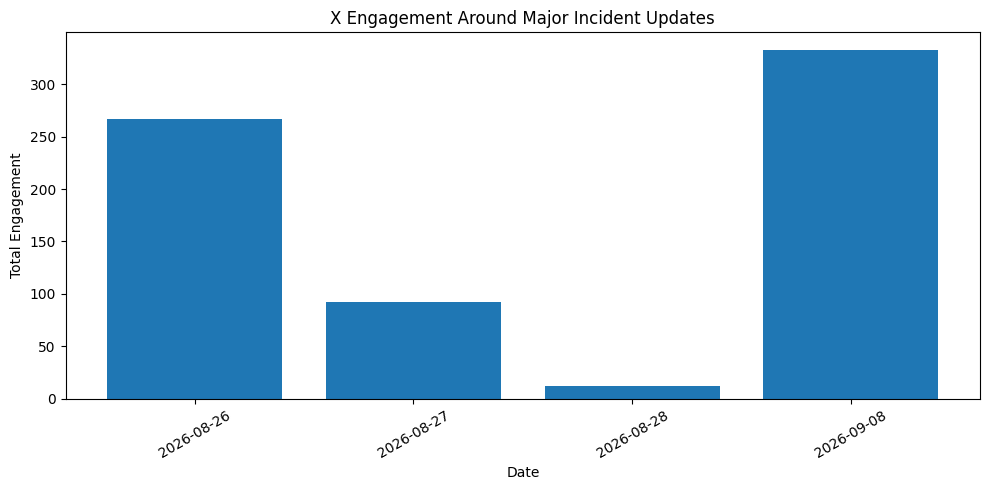

In [82]:
# Create a chronological daily activity table for the major
# trigger dates.
trigger_dates = [
    pd.to_datetime("2026-08-26").date(),
    pd.to_datetime("2026-08-27").date(),
    pd.to_datetime("2026-08-28").date(),
    pd.to_datetime("2026-09-08").date()
]

# Filter the daily X engagement table to the selected trigger dates.
trigger_activity = daily_x_engagement[
    daily_x_engagement["date"].isin(trigger_dates)
].copy()

# Sort the selected dates chronologically.
trigger_activity = trigger_activity.sort_values("date")

# Create a bar chart showing X engagement during the major
# trigger periods.
plt.figure(figsize=(10, 5))

plt.bar(
    trigger_activity["date"].astype(str),
    trigger_activity["total_engagement"]
)

# Add descriptive labels to the chart.
plt.title("X Engagement Around Major Incident Updates")
plt.xlabel("Date")
plt.ylabel("Total Engagement")

# Rotate date labels for readability.
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [83]:
# Create a manually structured interpretation table connecting
# each major incident stage with the observed conversation changes.
#
# The descriptions are based only on patterns already identified
# in the Round 3 dataset.

trigger_analysis = pd.DataFrame({
    "period": [
        "26 August",
        "27–28 August",
        "8 September"
    ],

    "trigger": [
        "Initial cyberattack and global operational disruption",
        "Medical-device, transmitter, remote-monitoring and service updates",
        "Financial guidance, continued disruption and recovery updates"
    ],

    "observed_change": [
        "High initial activity with strong operational and shipping discussion",
        "Technical_Issues predictions first appeared; patient/service-related discussion remained limited",
        "Highest dataset volume and X engagement; financial-impact discussion became dominant"
    ],

    "supporting_signal": [
        "44 records; 267 X engagements; 79.55% operational-disruption theme",
        "2 Technical_Issues predictions; patient/service-related records",
        "50 records; 333 X engagements; 82% financial-impact theme; 6 Technical_Issues predictions"
    ]
})

# Display the final trigger-analysis table.
display(trigger_analysis)

,period,trigger,observed_change,supporting_signal
0,26 August,Initial cyberattack and global operational disruption,High initial activity with strong operational and shipping discussion,44 records; 267 X engagements; 79.55% operational-disruption theme
1,27–28 August,"Medical-device, transmitter, remote-monitoring and service updates",Technical_Issues predictions first appeared; patient/service-related discussion remained limited,2 Technical_Issues predictions; patient/service-related records
2,8 September,"Financial guidance, continued disruption and recovery updates",Highest dataset volume and X engagement; financial-impact discussion became dominant,50 records; 333 X engagements; 82% financial-impact theme; 6 Technical_Issues predictions


### Trigger Analysis — Key Insights

The trigger analysis shows a clear evolution in the focus of the conversation across the major incident periods.

#### 1. Initial Incident — 26 August

The initial incident period recorded **44 records**, **22 X posts**, and **267 total X engagements**.

The conversation was primarily focused on the immediate operational consequences of the cyberattack. The Operational Disruption theme appeared in **79.55%** of records, while Shipping & Medical Devices appeared in **40.91%**.

The sentiment composition was **22.73% Negative, 50.00% Neutral, and 27.27% Positive**, indicating that Neutral predictions formed the largest share during the initial reporting period.

**Insight:** The initial conversation was mainly concerned with understanding the cyberattack and its immediate effects on operations and shipping.

---

#### 2. Device & Service Updates — 27–28 August

The 27–28 August period contained **38 records** and **21 X posts**, generating **104 total X engagements**.

This period introduced more specific discussion around medical-device services, transmitters, remote monitoring, and affected systems. The Round 2 topic model produced its first **2 Technical_Issues predictions** during this period.

Sentiment predictions were **28.95% Negative, 52.63% Neutral, and 18.42% Positive**.

**Insight:** The conversation began moving from general incident reporting toward more specific technical and medical-device service implications. However, the relatively small number of Technical_Issues predictions means this should be interpreted as an emerging signal rather than a large topic shift.

---

#### 3. Financial & Recovery Update — 8 September

The 8 September period recorded the highest activity, with **50 records**, **29 X posts**, and **333 total X engagements**.

The Financial Impact theme appeared in **82% of records**, compared with **20.45% on 26 August**. This represents an increase of **61.55 percentage points**.

The period also contained **6 Technical_Issues predictions**, compared with zero on 26 August.

Sentiment predictions were **36.00% Negative, 50.00% Neutral, and 14.00% Positive**.

**Insight:** By 8 September, the conversation had expanded beyond the immediate operational disruption toward the financial consequences of the incident, while technical and recovery-related discussion also became more visible.

---

### Overall Trigger Evolution

Across the three periods, the conversation shows a progression:

**Initial cyberattack and operational disruption → medical-device and service implications → financial impact and recovery**

The strongest observable change was the rise in the **Financial Impact** theme, from **20.45% on 26 August to 82.00% on 8 September**.

At the same time, X engagement increased from **267 to 333**, and Technical_Issues predictions increased from **0 to 6** between these two major periods.

These patterns indicate that the discussion became broader and increasingly focused on the business and operational consequences of the incident as new updates emerged.

The trigger analysis identifies temporal associations rather than proving that any individual update directly caused the observed changes.

# 14. Required Sentiment Shifts

The Round 3 requirements specify that the analysis should identify at least two sentiment shifts during the incident timeline.

Sentiment labels in this section are predictions generated using the exact Round 2 TF-IDF + Logistic Regression model. They should therefore be interpreted as model-classified sentiment rather than manually verified ground truth.

The analysis compares sentiment composition across periods with sufficient conversation volume and identifies the corresponding changes in Negative, Neutral, and Positive predictions.

In [84]:
# Create a copy of the sentiment dataframe for temporal analysis.
sentiment_shift_df = sentiment_df.copy()

# Extract the calendar date from the UTC timestamp.
sentiment_shift_df["date"] = sentiment_shift_df["timestamp"].dt.date

# Define the two major periods used for the primary sentiment comparison.
shift_periods = {
    "26 August": [
        pd.to_datetime("2026-08-26").date()
    ],

    "8 September": [
        pd.to_datetime("2026-09-08").date()
    ]
}

# Store sentiment percentages for each major period.
shift_results = []

for period, dates in shift_periods.items():

    # Select records belonging to the current period.
    period_data = sentiment_shift_df[
        sentiment_shift_df["date"].isin(dates)
    ]

    # Calculate the percentage of each predicted sentiment class.
    sentiment_pct = (
        period_data["sentiment_label"]
        .value_counts(normalize=True)
        .mul(100)
    )

    # Store the sentiment composition.
    shift_results.append({
        "period": period,
        "records": len(period_data),
        "negative_pct": sentiment_pct.get("Negative", 0),
        "neutral_pct": sentiment_pct.get("Neutral", 0),
        "positive_pct": sentiment_pct.get("Positive", 0)
    })

# Convert the results into a dataframe.
shift_table = pd.DataFrame(shift_results)

# Display the sentiment composition of the two major periods.
display(shift_table)

,period,records,negative_pct,neutral_pct,positive_pct
0,26 August,44,22.727273,50.0,27.272727
1,8 September,50,36.000000,50.0,14.000000


In [85]:
# Extract the two major-period sentiment values.
initial_period = shift_table.iloc[0]
later_period = shift_table.iloc[1]

# Calculate the change in percentage points for each sentiment class.
sentiment_changes = pd.DataFrame({
    "sentiment": [
        "Negative",
        "Neutral",
        "Positive"
    ],

    "26_August_pct": [
        initial_period["negative_pct"],
        initial_period["neutral_pct"],
        initial_period["positive_pct"]
    ],

    "8_September_pct": [
        later_period["negative_pct"],
        later_period["neutral_pct"],
        later_period["positive_pct"]
    ]
})

# Calculate the percentage-point change between the two periods.
sentiment_changes["change_pp"] = (
    sentiment_changes["8_September_pct"]
    - sentiment_changes["26_August_pct"]
)

# Round the values for presentation.
sentiment_changes = sentiment_changes.round(2)

# Display the sentiment shift.
display(sentiment_changes)

,sentiment,26_August_pct,8_September_pct,change_pp
0,Negative,22.73,36.0,13.27
1,Neutral,50.00,50.0,0.00
2,Positive,27.27,14.0,-13.27


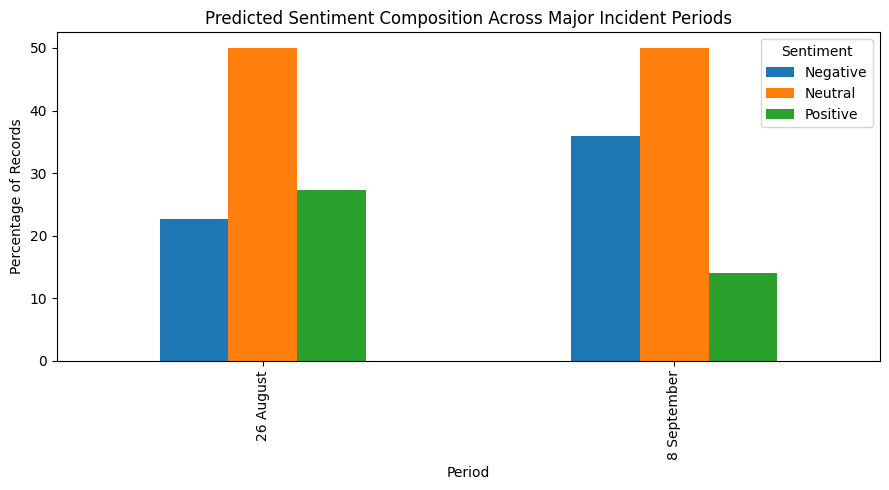

In [86]:
# Create a grouped bar chart comparing predicted sentiment
# composition between the two major incident periods.

sentiment_plot = shift_table.set_index("period")[
    ["negative_pct", "neutral_pct", "positive_pct"]
]

# Rename the columns for clearer chart labels.
sentiment_plot.columns = [
    "Negative",
    "Neutral",
    "Positive"
]

# Create the grouped bar chart.
sentiment_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

# Add descriptive chart labels.
plt.title("Predicted Sentiment Composition Across Major Incident Periods")
plt.xlabel("Period")
plt.ylabel("Percentage of Records")

# Keep the legend visible.
plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

### Sentiment Shift 1 — 26 August to 8 September

The strongest high-volume sentiment change occurred between **26 August and 8 September**.

On 26 August:

- Negative: **22.73%**
- Neutral: **50.00%**
- Positive: **27.27%**

On 8 September:

- Negative: **36.00%**
- Neutral: **50.00%**
- Positive: **14.00%**

Therefore:

- Negative predictions increased by **13.27 percentage points**
- Neutral predictions remained unchanged
- Positive predictions decreased by **13.27 percentage points**

This shift coincided with the 8 September increase in discussion around financial impact, continued operational disruption, shipping consequences, and recovery updates.

The Financial Impact theme increased from **20.45% of records on 26 August to 82.00% on 8 September**, while X engagement increased from **267 to 333**.

The sentiment change should be interpreted as a **model-classified shift** rather than a definitive measurement of public sentiment, given the Round 2 sentiment model's performance.

In [87]:
# Calculate the sentiment composition for 26 and 27 August
# to identify a second temporal sentiment shift.

second_shift_dates = [
    pd.to_datetime("2026-08-26").date(),
    pd.to_datetime("2026-08-27").date()
]

second_shift_data = sentiment_shift_df[
    sentiment_shift_df["date"].isin(second_shift_dates)
].copy()

# Calculate sentiment percentages for each date.
second_shift_table = (
    second_shift_data
    .groupby(["date", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)

# Convert counts into percentages within each date.
second_shift_pct = (
    second_shift_table
    .div(second_shift_table.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

# Ensure all three sentiment classes appear as columns.
second_shift_pct = second_shift_pct.reindex(
    columns=["Negative", "Neutral", "Positive"],
    fill_value=0
)

# Display the comparison.
display(second_shift_pct)

sentiment_label,Negative,Neutral,Positive
date,,,
2026-08-26,22.73,50.00,27.27
2026-08-27,30.00,46.67,23.33


### Sentiment Shift 2 — 26 August to 27 August

A second sentiment shift was observed between **26 and 27 August**.

The Negative prediction share increased from **22.73% to 30.00%**, an increase of **7.27 percentage points**.

At the same time:

- Neutral decreased from **50.00% to 46.67%** (**−3.33 pp**)
- Positive decreased from **27.27% to 23.33%** (**−3.94 pp**)

The change occurred alongside the continuation of discussion about the cyberattack and its operational consequences.

However, the number of records decreased from **44 on 26 August to 30 on 27 August**, so this shift has less volume support than the 26 August → 8 September comparison.

It should therefore be treated as a smaller short-term change in model predictions rather than evidence of a definitive change in public sentiment.

### Sentiment Model Reliability

The Round 2 sentiment model used for all Round 3 predictions achieved:

- **Accuracy:** 57.34%
- **Macro F1:** 0.5730
- **Macro Precision:** 0.5731
- **Macro Recall:** 0.5730

The Round 2 confusion matrix also showed substantial confusion involving the Neutral class, including:

- Neutral → Negative: **189**
- Positive → Neutral: **186**
- Negative → Neutral: **177**
- Neutral → Positive: **169**

Therefore, the sentiment shifts identified in Round 3 are best interpreted as **directional model signals**.

The strongest finding is the change in predicted sentiment composition between 26 August and 8 September, where Negative predictions increased by **13.27 percentage points** and Positive predictions decreased by **13.27 percentage points** across two relatively high-volume periods.

# 15. Final Dataset Validation

Before exporting the final Round 3 dataset, the data is validated against the required submission schema.

The final dataset must contain exactly these nine fields:

1. text_id
2. source
3. post_text
4. timestamp
5. likes
6. comments
7. shares
8. sentiment_label
9. topic_category

The validation checks:

- Dataset shape
- Exact column names and order
- Duplicate text IDs
- Duplicate post text
- Missing required values
- Timestamp validity
- Valid source labels
- Valid sentiment labels
- Valid topic labels
- Availability of engagement fields for X records
- Missing engagement values for news records

In [88]:
# Create the final Round 3 dataset using the predicted sentiment
# and topic labels generated from the exact Round 2 models.

final_columns = [
    "text_id",
    "source",
    "post_text",
    "timestamp",
    "likes",
    "comments",
    "shares",
    "sentiment_label",
    "topic_category"
]

# Select only the required nine fields in the required order.
final_df = topic_df[final_columns].copy()

# Display the final dataset shape and first few records.
print("Final dataset shape:", final_df.shape)
display(final_df.head())

Final dataset shape: (190, 9)


,text_id,source,post_text,timestamp,likes,comments,shares,sentiment_label,topic_category
0,news_0049,news,Cyberattack disrupts Boston Scientific as medtech incidents mount - Insurance Business,2026-08-26 07:00:00+00:00,NaN,NaN,NaN,Negative,Community_Discussion
1,news_0018,news,"Boston Scientific’s ordering, shipping disrupted in cyberattack - MedTech Dive",2026-08-26 07:00:00+00:00,NaN,NaN,NaN,Neutral,Community_Discussion
2,news_0024,news,"Boston Scientific hit by cyberattack, global operations affected - Reuters",2026-08-26 07:00:00+00:00,NaN,NaN,NaN,Positive,Community_Discussion
3,news_0011,news,"Boston Scientific says cyberattack disrupted order processing, shipping - Cybersecurity Dive",2026-08-26 07:00:00+00:00,NaN,NaN,NaN,Negative,Community_Discussion
4,news_0032,news,Cyberattack on Boston Scientific Disrupts Order Processing - mddionline.com,2026-08-26 07:00:00+00:00,NaN,NaN,NaN,Neutral,Community_Discussion


In [89]:
# Define the exact schema required for the Round 3 submission.
expected_columns = [
    "text_id",
    "source",
    "post_text",
    "timestamp",
    "likes",
    "comments",
    "shares",
    "sentiment_label",
    "topic_category"
]

# Check whether the final dataset has exactly the expected columns
# in exactly the expected order.
schema_valid = list(final_df.columns) == expected_columns

print("Schema valid:", schema_valid)
print("Actual columns:", list(final_df.columns))
print("Expected columns:", expected_columns)

Schema valid: True
Actual columns: ['text_id', 'source', 'post_text', 'timestamp', 'likes', 'comments', 'shares', 'sentiment_label', 'topic_category']
Expected columns: ['text_id', 'source', 'post_text', 'timestamp', 'likes', 'comments', 'shares', 'sentiment_label', 'topic_category']


In [90]:
# Check for duplicate text IDs and duplicate post text.
duplicate_ids = final_df["text_id"].duplicated().sum()
duplicate_text = final_df["post_text"].duplicated().sum()

# Check missing values in the fields that must always be populated.
required_non_null_columns = [
    "text_id",
    "source",
    "post_text",
    "timestamp",
    "sentiment_label",
    "topic_category"
]

missing_required = final_df[
    required_non_null_columns
].isna().sum()

# Display the duplicate and missing-value checks.
print("Duplicate text IDs:", duplicate_ids)
print("Duplicate post texts:", duplicate_text)

print("\nMissing values in required fields:")
display(missing_required)

Duplicate text IDs: 0
Duplicate post texts: 0

Missing values in required fields:


,0
text_id,0
source,0
post_text,0
timestamp,0
sentiment_label,0
topic_category,0


In [91]:
# Define the valid source and prediction labels expected
# in the final dataset.
valid_sources = {
    "twitter",
    "news"
}

valid_sentiments = {
    "Negative",
    "Neutral",
    "Positive"
}

valid_topics = {
    "Account_Security",
    "Community_Discussion",
    "Feature_Feedback",
    "Technical_Issues"
}

# Identify any unexpected source values.
invalid_sources = set(final_df["source"].dropna().unique()) - valid_sources

# Identify any unexpected sentiment labels.
invalid_sentiments = (
    set(final_df["sentiment_label"].dropna().unique())
    - valid_sentiments
)

# Identify any unexpected topic labels.
invalid_topics = (
    set(final_df["topic_category"].dropna().unique())
    - valid_topics
)

# Display the validation results.
print("Invalid source values:", invalid_sources)
print("Invalid sentiment values:", invalid_sentiments)
print("Invalid topic values:", invalid_topics)

Invalid source values: set()
Invalid sentiment values: set()
Invalid topic values: set()


In [92]:
# Separate X and news records to validate engagement fields
# according to what was actually available during collection.

twitter_df = final_df[
    final_df["source"] == "twitter"
]

news_df = final_df[
    final_df["source"] == "news"
]

# Check whether X records have missing engagement values.
twitter_missing_engagement = twitter_df[
    ["likes", "comments", "shares"]
].isna().sum()

# Check the number of missing engagement values for news records.
news_missing_engagement = news_df[
    ["likes", "comments", "shares"]
].isna().sum()

print("X records:", len(twitter_df))
print("News records:", len(news_df))

print("\nMissing engagement values in X records:")
display(twitter_missing_engagement)

print("\nMissing engagement values in news records:")
display(news_missing_engagement)

X records: 93
News records: 97

Missing engagement values in X records:


,0
likes,0
comments,0
shares,0



Missing engagement values in news records:


,0
likes,97
comments,97
shares,97


In [93]:
# Create a compact validation summary for the final dataset.

validation_summary = {
    "Rows": len(final_df),
    "Columns": len(final_df.columns),
    "Schema valid": schema_valid,
    "Duplicate text IDs": duplicate_ids,
    "Duplicate post texts": duplicate_text,
    "Missing required values": int(
        missing_required.sum()
    ),
    "Invalid source values": len(invalid_sources),
    "Invalid sentiment values": len(invalid_sentiments),
    "Invalid topic values": len(invalid_topics),
    "Twitter records": len(twitter_df),
    "News records": len(news_df)
}

# Convert the validation summary into a dataframe for easy review.
validation_summary_df = pd.DataFrame(
    list(validation_summary.items()),
    columns=["Check", "Result"]
)

display(validation_summary_df)

,Check,Result
0,Rows,190
1,Columns,9
2,Schema valid,True
3,Duplicate text IDs,0
4,Duplicate post texts,0
5,Missing required values,0
6,Invalid source values,0
7,Invalid sentiment values,0
8,Invalid topic values,0
9,Twitter records,93


#16. Export Final Dataset

The validated nine-column dataset is exported as the final Round 3 analysis dataset.

No additional analysis-only columns are included in the exported file.

In [94]:
# Define the filename for the final Round 3 submission dataset.
final_output_path = "Tekton_Round3_Final_Dataset.csv"

# Export only the validated nine-column dataset.
final_df.to_csv(
    final_output_path,
    index=False
)

# Confirm that the file was created successfully.
print("Final dataset exported successfully.")
print("File:", final_output_path)
print("Rows:", len(final_df))
print("Columns:", len(final_df.columns))

Final dataset exported successfully.
File: Tekton_Round3_Final_Dataset.csv
Rows: 190
Columns: 9


In [95]:
# Reload the exported CSV to verify that the saved file
# can be read correctly and retains the required schema.

export_check = pd.read_csv(final_output_path)

# Display the saved file's shape and columns.
print("Reloaded exported dataset successfully.")
print("Shape:", export_check.shape)
print("Columns:", list(export_check.columns))

# Confirm that the exported schema matches the required schema.
print(
    "Export schema valid:",
    list(export_check.columns) == expected_columns
)

# Display a sample of the exported dataset.
display(export_check.head())

Reloaded exported dataset successfully.
Shape: (190, 9)
Columns: ['text_id', 'source', 'post_text', 'timestamp', 'likes', 'comments', 'shares', 'sentiment_label', 'topic_category']
Export schema valid: True


,text_id,source,post_text,timestamp,likes,comments,shares,sentiment_label,topic_category
0,news_0049,news,Cyberattack disrupts Boston Scientific as medtech incidents mount - Insurance Business,2026-08-26 07:00:00+00:00,NaN,NaN,NaN,Negative,Community_Discussion
1,news_0018,news,"Boston Scientific’s ordering, shipping disrupted in cyberattack - MedTech Dive",2026-08-26 07:00:00+00:00,NaN,NaN,NaN,Neutral,Community_Discussion
2,news_0024,news,"Boston Scientific hit by cyberattack, global operations affected - Reuters",2026-08-26 07:00:00+00:00,NaN,NaN,NaN,Positive,Community_Discussion
3,news_0011,news,"Boston Scientific says cyberattack disrupted order processing, shipping - Cybersecurity Dive",2026-08-26 07:00:00+00:00,NaN,NaN,NaN,Negative,Community_Discussion
4,news_0032,news,Cyberattack on Boston Scientific Disrupts Order Processing - mddionline.com,2026-08-26 07:00:00+00:00,NaN,NaN,NaN,Neutral,Community_Discussion
